# Student Financial Behaviour Analysis
## FinTech Product: *StepStone* - Helping Students Progress Toward Long-Term Financial Goals

**Product concept**: An app that coaches Irish university students toward long-term financial goals such as buying their first home, buying their first investment property, building an investment portfolio, or even retiring early. In this analysis, I focus on the first-home scenario.

The app analyses a student's financial situation and financial behaviour, then shows them when they can achieve their goal under several different behavioural patterns. This is designed to motivate users to increase their effort toward their goals and reach them sooner.

**Core hypothesis**: Students living with their parents enjoy a natural cost advantage through lower essential spending, which gives them stronger potential to save and achieve long-term financial goals sooner. However, many waste significant part of this surplus on discretionary spending. By improving financial literacy and giving students more structure, the app can reduce unnecessary spending, increase savings, and make them more financially successful in the future.

**Analysis roadmap**:
1. **Data Cleaning** - prepare the student spending survey for analysis
2. **Exploratory Data Analysis** - understand spending, balances, and saving capacity across groups
3. **Regression Analysis** - model what drives saving potential and discretionary spending, with focus on living situation
4. **Time Series Forecasting** - forecast Irish house prices to estimate the path to homeownership
5. **Business Case** - quantify how the app accelerates the path to a mortgage deposit


## Section 2: Imports

In [1]:
import numpy as np                                              # numerical operations (arrays, math)
import pandas as pd                                             # data manipulation and DataFrames
import statsmodels.api as sm                                    # OLS regression models
import statsmodels.tsa.api as smt                               # time series models (ARIMA, ARMA order selection)
import statsmodels.tsa.stattools as st                          # stationarity tests (ADF)
from statsmodels.stats.diagnostic import het_white              # White's test for heteroskedasticity
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF for multicollinearity
from scipy.stats import ttest_ind, chi2_contingency             # t-tests and chi-square for MCAR testing
import matplotlib.pyplot as plt                                 # plotting and visualisation
import seaborn as sns                                           # statistical visualisation (heatmaps, boxplots)
import warnings                                                 # suppress convergence warnings in grid search

## Section 3: Data Loading

We load the student spending survey dataset (1,026 responses). This is a cross-sectional survey of Irish university students capturing demographics, employment, income, living arrangements, parental support, spending behaviour, and current savings balances. Data has been mocked up using Claude Opus 4.6.

These variables allow us to study both the students' current financial position and their potential to make faster progress toward long-term goals such as homeownership.


In [2]:
# 3.1 — Load the raw survey data and inspect its structure
# We check: number of rows/columns, data types (numeric vs categorical),
# and preview the first rows to spot obvious issues (missing values, formatting).
df = pd.read_csv('data/student_spending_survey.csv')

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Column types:")
print(df.dtypes)
print("\nColumns:")
print(df.columns.tolist())
print("\n--- First 5 rows ---")
df.head()

Dataset shape: 1026 rows x 13 columns

Column types:
student_id                     int64
age                            int64
sex                           object
field_of_study                object
year_of_study                  int64
employment_status             object
income_highest_month         float64
income_lowest_month          float64
living_with_parents           object
financial_support_parents    float64
essential_spending             int64
discretionary_spending       float64
current_savings_balance        int64
dtype: object

Columns:
['student_id', 'age', 'sex', 'field_of_study', 'year_of_study', 'employment_status', 'income_highest_month', 'income_lowest_month', 'living_with_parents', 'financial_support_parents', 'essential_spending', 'discretionary_spending', 'current_savings_balance']

--- First 5 rows ---


,student_id,age,sex,field_of_study,year_of_study,employment_status,income_highest_month,income_lowest_month,living_with_parents,financial_support_parents,essential_spending,discretionary_spending,current_savings_balance
0,429,20,Female,Health Sciences,2,Unemployed,NaN,0.0,Yes,0.0,270,80.0,75
1,533,22,Female,business,4,Part-time,870.0,440.0,No,650.0,680,170.0,26500
2,389,20,Female,Business,3,Freelance,2190.0,300.0,Yes,0.0,240,350.0,8100
3,108,21,Male,STEM,3,Unemployed,0.0,0.0,Yes,0.0,280,50.0,175
4,424,20,Male,Social Sciences,2,Part-time,1030.0,530.0,No,50.0,580,190.0,1275


## Section 4: Data Cleaning

Before any analysis, we need to address data quality issues common in survey data:
1. **Missing values** — some respondents left fields blank
2. **Inconsistent labels** — typos and case variations in categorical fields
3. **Duplicate entries** — repeated submissions
4. **Outliers** — data points unusually far from the rest 

We will systematically identify each issue, assess whether missing data is random (MCAR test), and then clean the dataset.

In [3]:
# 4.1 — Check missing values per column
# Identify which columns have gaps and how many rows are affected.
# This informs whether we can safely drop incomplete rows (if few)
# or need imputation (if many).
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Rows with at least one missing value: {df.isnull().any(axis=1).sum()}")

Missing values per column:
student_id                    0
age                           0
sex                           0
field_of_study                0
year_of_study                 0
employment_status             0
income_highest_month         11
income_lowest_month          11
living_with_parents           0
financial_support_parents    12
essential_spending            0
discretionary_spending       14
current_savings_balance       0
dtype: int64

Total missing values: 48
Rows with at least one missing value: 47


In [4]:
# 4.2 — Check field_of_study for inconsistent labels (typos, case issues)
# Categorical variables must have clean, consistent labels before we can
# create dummy variables for regression. Any typos or case mismatches
# would create spurious categories.
print("Unique field_of_study values:")
print(df['field_of_study'].value_counts())

Unique field_of_study values:
field_of_study
Business             267
STEM                 264
Arts & Humanities    218
Health Sciences      140
Social Sciences      131
business               1
stem                   1
Busines                1
Social Sciences        1
Health sciences        1
Arts & humanities      1
Name: count, dtype: int64


In [5]:
# 4.3 — Fix field_of_study: strip whitespace, map typos to standard labels
# We see entries like "business", "Busines", "stem", "Arts & humanities",
# "Health sciences", "Social Sciences " (trailing space).
# These are clearly the same categories with typos or case differences.

df['field_of_study'] = df['field_of_study'].str.strip()  # remove leading/trailing whitespace

# Map all known variations to their correct standard labels
field_mapping = {
    'business': 'Business',
    'Busines': 'Business',
    'stem': 'STEM',
    'Arts & humanities': 'Arts & Humanities',
    'Health sciences': 'Health Sciences',
}
df['field_of_study'] = df['field_of_study'].replace(field_mapping)

# Verify fix — should show exactly 5 clean categories
print("After cleaning — unique field_of_study values:")
print(df['field_of_study'].value_counts())

After cleaning — unique field_of_study values:
field_of_study
Business             269
STEM                 265
Arts & Humanities    219
Health Sciences      141
Social Sciences      132
Name: count, dtype: int64


### 4.4 - Financial Validity Checks

Before testing missingness, we verify that the raw survey finance variables satisfy basic logical constraints. In this dataset:
- income variables should not be negative
- financial support should not be negative
- spending variables should not be negative
- current savings balance should not be negative
- `income_lowest_month` should be less than or equal to `income_highest_month` for each student

These are essential validity checks because financial variables can vary widely across students, but they must still remain economically possible.


In [6]:
# 4.4 - Check for impossible financial values
validity_checks = {
    'Negative values in income_highest_month': int((df['income_highest_month'].dropna() < 0).sum()),
    'Negative values in income_lowest_month': int((df['income_lowest_month'].dropna() < 0).sum()),
    'Negative values in financial_support_parents': int((df['financial_support_parents'].dropna() < 0).sum()),
    'Negative values in essential_spending': int((df['essential_spending'].dropna() < 0).sum()),
    'Negative values in discretionary_spending': int((df['discretionary_spending'].dropna() < 0).sum()),
    'Negative values in current_savings_balance': int((df['current_savings_balance'].dropna() < 0).sum()),
    'income_lowest_month > income_highest_month': int(((df['income_lowest_month'].notna())
                                                  & (df['income_highest_month'].notna())
                                                  & (df['income_lowest_month'] > df['income_highest_month'])).sum())
}

print('Financial validity checks:\n')
for check, count in validity_checks.items():
    print(f'{check}: {count}')

print('\nInterpretation: zero violations means the raw financial variables satisfy the key logical constraints.')


Financial validity checks:

Negative values in income_highest_month: 0
Negative values in income_lowest_month: 0
Negative values in financial_support_parents: 0
Negative values in essential_spending: 0
Negative values in discretionary_spending: 0
Negative values in current_savings_balance: 0
income_lowest_month > income_highest_month: 0

Interpretation: zero violations means the raw financial variables satisfy the key logical constraints.


### 4.5 - MCAR Test (Missing Completely At Random)

Before dropping rows with missing values, we must check whether the missingness is **random** or **systematic**. If data is Missing Completely At Random (MCAR), then listwise deletion (dropping incomplete rows) does not introduce bias.

**Method**: For each column with missing values, we create a binary indicator (1 = missing, 0 = observed). Then:
- **t-tests**: compare means of numeric variables between the missing and non-missing groups
- **Chi-square tests**: test whether missingness is associated with categorical variables

If all p-values are above 0.05, we conclude there is no systematic pattern and listwise deletion is appropriate.


In [7]:
# 4.5 - MCAR testing: check if missingness is random
# Columns with missing values
cols_with_na = df.columns[df.isnull().any()].tolist()
print(f"Columns with missing values: {cols_with_na}\n")

# Numeric columns to compare (excluding the ones being tested for missingness)
numeric_cols = ['age', 'year_of_study', 'essential_spending', 'current_savings_balance']
# Categorical columns to test association with
cat_cols = ['sex', 'employment_status', 'living_with_parents', 'field_of_study']

results = []

for col in cols_with_na:
    missing_indicator = df[col].isnull()

    for num_col in numeric_cols:
        group_missing = df.loc[missing_indicator, num_col].dropna()
        group_observed = df.loc[~missing_indicator, num_col].dropna()
        if len(group_missing) >= 2 and len(group_observed) >= 2:
            t_stat, p_val = ttest_ind(group_missing, group_observed)
            results.append({
                'missing_col': col,
                'test_var': num_col,
                'test': 't-test',
                'statistic': round(t_stat, 3),
                'p_value': round(p_val, 4)
            })

    for cat_col in cat_cols:
        contingency = pd.crosstab(missing_indicator, df[cat_col])
        if contingency.shape[0] == 2 and contingency.shape[1] >= 2:
            chi2, p_val, dof, expected = chi2_contingency(contingency)
            results.append({
                'missing_col': col,
                'test_var': cat_col,
                'test': 'chi-square',
                'statistic': round(chi2, 3),
                'p_value': round(p_val, 4)
            })

results_df = pd.DataFrame(results)
print(f"Total tests conducted: {len(results_df)}")
print(f"Tests with p < 0.05 (significant): {(results_df['p_value'] < 0.05).sum()}\n")
results_df


Columns with missing values: ['income_highest_month', 'income_lowest_month', 'financial_support_parents', 'discretionary_spending']

Total tests conducted: 32
Tests with p < 0.05 (significant): 1



,missing_col,test_var,test,statistic,p_value
0,income_highest_month,age,t-test,0.598,0.5501
1,income_highest_month,year_of_study,t-test,0.612,0.5406
2,income_highest_month,essential_spending,t-test,-0.445,0.6564
3,income_highest_month,current_savings_balance,t-test,0.707,0.4799
4,income_highest_month,sex,chi-square,0.477,0.4896
5,income_highest_month,employment_status,chi-square,0.895,0.8267
6,income_highest_month,living_with_parents,chi-square,0.000,1.0000
7,income_highest_month,field_of_study,chi-square,4.234,0.3752
8,income_lowest_month,age,t-test,-0.859,0.3904
9,income_lowest_month,year_of_study,t-test,-2.404,0.0164


**MCAR Interpretation**: Out of 32 tests, only 1 shows a p-value below 0.05. With 32 tests conducted at the 5% significance level, we would expect around 1-2 false positives by chance alone (32 x 0.05 = 1.6). A single significant result does not suggest a systematic missingness pattern.

The evidence is therefore broadly consistent with the data being **Missing Completely At Random (MCAR)**, which means listwise deletion (dropping rows with any missing value) is a reasonable and defensible approach for this analysis.


In [8]:
# 4.6 - Drop rows with missing values (justified by MCAR evidence above)
print(f"Shape before dropping NaN: {df.shape}")
df = df.dropna()
print(f"Shape after dropping NaN:  {df.shape}")
print(f"Remaining missing values:  {df.isnull().sum().sum()}")


Shape before dropping NaN: (1026, 13)
Shape after dropping NaN:  (979, 13)
Remaining missing values:  0


In [9]:
# 4.7 - Remove duplicate rows
print(f"Duplicate rows found: {df.duplicated().sum()}")
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")


Duplicate rows found: 2
Shape after removing duplicates: (977, 13)


In [10]:
# 4.8 - Verify clean state
print(f"Final shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Unique field_of_study: {df['field_of_study'].unique()}")
print(f"\nData types:\n{df.dtypes}")


Final shape: (977, 13)
Missing values: 0
Duplicates: 0
Unique field_of_study: ['Business' 'STEM' 'Social Sciences' 'Arts & Humanities' 'Health Sciences']

Data types:
student_id                     int64
age                            int64
sex                           object
field_of_study                object
year_of_study                  int64
employment_status             object
income_highest_month         float64
income_lowest_month          float64
living_with_parents           object
financial_support_parents    float64
essential_spending             int64
discretionary_spending       float64
current_savings_balance        int64
dtype: object


### 4.9 - Outlier Inspection

We inspect potential outliers visually using **boxplots** before making any decision about removing them. In financial data, extreme values are not automatically errors - they may reflect real differences in student income, support, or savings.

We therefore use this step to **identify** unusual observations, assess whether they look economically plausible, and decide whether they should be retained for the later analysis.


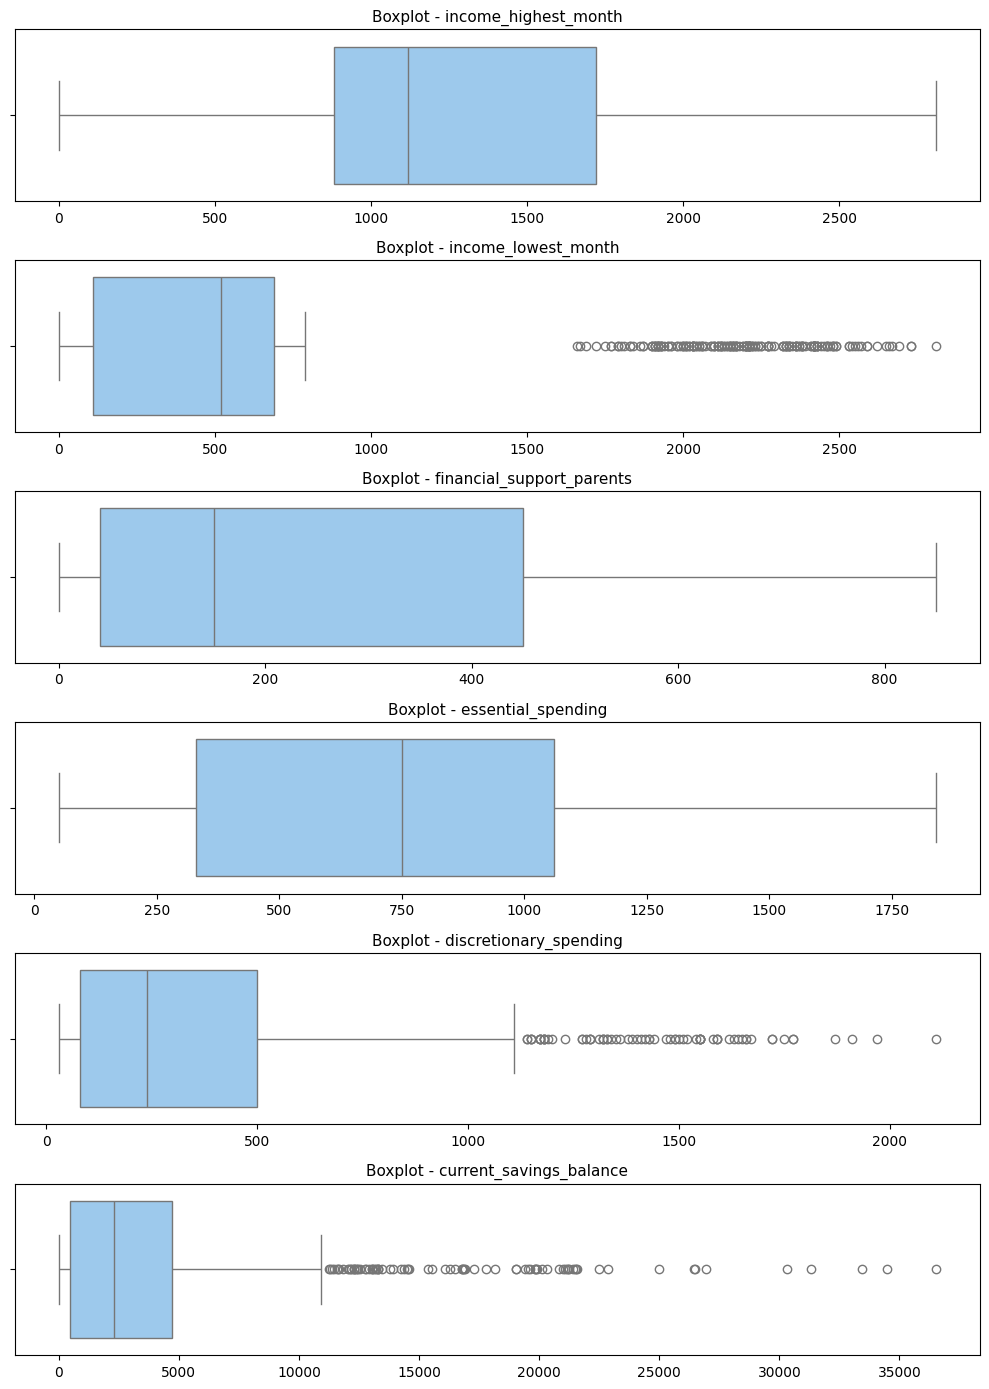

Potential outliers based on the 1.5*IQR rule:

                 Variable    Q1     Q3    IQR  Lower bound  Upper bound  Potential outliers
     income_highest_month 880.0 1720.0  840.0       -380.0       2980.0                   0
      income_lowest_month 110.0  690.0  580.0       -760.0       1560.0                 185
financial_support_parents  40.0  450.0  410.0       -575.0       1065.0                   0
       essential_spending 330.0 1060.0  730.0       -765.0       2155.0                   0
   discretionary_spending  80.0  500.0  420.0       -550.0       1130.0                  72
  current_savings_balance 475.0 4725.0 4250.0      -5900.0      11100.0                  83

Interpretation: the flagged observations are inspected but retained,
because they remain economically plausible for heterogeneous student finances.


In [11]:
# 4.9 - Inspect potential outliers with boxplots and the IQR rule
# This step asks a different question from the validity checks above.
# Here we are not looking for impossible values; instead, we are looking for
# observations that sit unusually far from the middle of the distribution.
# In finance-related survey data, such points may still be genuine, so they are
# inspected first rather than automatically removed.

# We keep the inspection focused on the original survey money variables so that
# the reader can assess unusual raw responses directly.
outlier_cols = ['income_highest_month', 'income_lowest_month', 'financial_support_parents',
                'essential_spending', 'discretionary_spending', 'current_savings_balance']

# Boxplots visualise the centre, spread, and tails of each variable.
# Points beyond the whiskers are potential outliers under the default boxplot rule.
fig, axes = plt.subplots(len(outlier_cols), 1, figsize=(10, 14))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(x=df[col], ax=ax, color='#90CAF9')
    ax.set_title(f'Boxplot - {col}', fontsize=11)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

# The 1.5*IQR rule is a standard numerical summary of the same idea.
# Q1 and Q3 are the 25th and 75th percentiles, and the interquartile range (IQR)
# measures the width of the middle 50% of the data.
# Any value below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is flagged as a potential outlier.
outlier_summary = []
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Count how many observations fall outside the standard IQR thresholds.
    # These are 'potential' outliers, not automatic errors.
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        'Variable': col,
        'Q1': round(q1, 1),
        'Q3': round(q3, 1),
        'IQR': round(iqr, 1),
        'Lower bound': round(lower, 1),
        'Upper bound': round(upper, 1),
        'Potential outliers': int(n_outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)
print('Potential outliers based on the 1.5*IQR rule:\n')
print(outlier_df.to_string(index=False))

print('\nInterpretation: the flagged observations are inspected but retained,')
print('because they remain economically plausible for heterogeneous student finances.')


## Section 5: Exploratory Data Analysis

Before building regression models, we explore the data to understand distributions and group differences. Our key comparison is between students **living with parents** and those **renting / living independently**.

This section begins with **feature engineering**, where we construct additional variables from the raw survey responses so that the financial patterns in the data can be analysed more clearly. The engineered variables are:
- `avg_income` - an estimate of typical monthly income, calculated as the midpoint between the highest-income and lowest-income month
- `income_std` - a measure of income volatility, showing how stable or unstable income is across months
- `monthly_savings` - an estimated monthly surplus after income and parental support are compared against essential and discretionary spending
- `saving_rate` - monthly savings expressed as a proportion of average income, which helps compare financial discipline across students with different income levels
- `saving_potential` - the amount remaining after essential spending only, which captures the student's structural room to save before discretionary choices are made

These variables help us distinguish between **financial capacity** and **financial behaviour**. In particular, `saving_potential` tells us how much a student could save based on their basic budget position, while `discretionary_spending` and `monthly_savings` help show whether that potential is actually converted into progress toward long-term goals.


In [12]:
# 5.1 — Feature Engineering: create derived columns from raw survey data
# We engineer new variables that capture financial behaviour patterns not directly
# observable in the raw data. These will serve as both EDA tools and regression predictors.

# --- Average monthly income ---
# The survey reports best and worst months; we take the midpoint as the typical month.
df['avg_income'] = (df['income_highest_month'] + df['income_lowest_month']) / 2

# --- Income volatility ---
# We use the half-range (max - min) / 2 as a proxy for income volatility.
# Note: this is NOT the formal standard deviation — we only have two data points
# per student (best and worst month), so the half-range is the best available
# measure of how much their income fluctuates.
df['income_std'] = (df['income_highest_month'] - df['income_lowest_month']) / 2

# --- Estimated monthly savings ---
# The raw survey includes current savings balance, but not an explicit monthly flow.
# We therefore engineer net monthly savings as the remaining surplus after essential
# and discretionary spending.
df['monthly_savings'] = (
    df['avg_income']
    + df['financial_support_parents']
    - df['essential_spending']
    - df['discretionary_spending']
)

# --- Saving rate ---
# Proportion of income that ends up as savings. Replace zero income with NaN to avoid
# division by zero.
df['saving_rate'] = df['monthly_savings'] / df['avg_income'].replace(0, np.nan)

# --- Saving potential ---
# The maximum a student COULD save if they had zero discretionary spending.
# This is the budget room available after essential costs.
df['saving_potential'] = df['avg_income'] + df['financial_support_parents'] - df['essential_spending']

print("Descriptive statistics for numeric variables:")
df.describe().round(1)

Descriptive statistics for numeric variables:


,student_id,age,year_of_study,income_highest_month,income_lowest_month,financial_support_parents,essential_spending,discretionary_spending,current_savings_balance,avg_income,income_std,monthly_savings,saving_rate,saving_potential
count,977.0,977.0,977.0,977.0,977.0,977.0,977.0,977.0,977.0,977.0,977.0,977.0,853.0,977.0
mean,511.9,20.5,2.3,1214.4,702.7,241.3,724.9,374.0,3921.4,958.5,255.9,101.0,0.1,475.0
std,296.8,1.9,1.1,705.4,765.8,248.2,402.4,401.0,5126.5,696.0,239.8,381.0,0.4,714.7
min,1.0,18.0,1.0,0.0,0.0,0.0,50.0,30.0,0.0,0.0,0.0,-1420.0,-4.8,-1340.0
25%,257.0,19.0,1.0,880.0,110.0,40.0,330.0,80.0,475.0,685.0,75.0,-105.0,0.0,-45.0
50%,513.0,20.0,2.0,1120.0,520.0,150.0,750.0,240.0,2300.0,825.0,215.0,110.0,0.2,400.0
75%,767.0,21.0,3.0,1720.0,690.0,450.0,1060.0,500.0,4725.0,985.0,345.0,270.0,0.3,730.0
max,1024.0,28.0,4.0,2810.0,2810.0,850.0,1840.0,2110.0,36525.0,2810.0,1050.0,1345.0,0.8,2620.0


In [13]:
# 5.2 — Group comparison: mean values by living situation
# This is the first direct test of our hypothesis: do at-home students have
# different financial profiles than renters? We compare mean income, spending,
# and savings across the two groups. Key things to look for:
#   - Higher saving_potential for at-home students (lower essential spending = no rent)
#   - Whether at-home students also have higher discretionary spending (overspend?)
comparison_cols = ['avg_income', 'financial_support_parents', 'essential_spending',
                   'discretionary_spending', 'monthly_savings', 'current_savings_balance']

group_means = df.groupby('living_with_parents')[comparison_cols].mean().round(1)
group_means.index.name = 'Living with parents'
print("Group comparison - mean values by living situation:\n")
group_means

Group comparison - mean values by living situation:



,avg_income,financial_support_parents,essential_spending,discretionary_spending,monthly_savings,current_savings_balance
Living with parents,,,,,,
No,1085.1,371.5,1017.0,344.4,95.2,4232.6
Yes,778.3,55.8,308.7,416.1,109.2,3478.2


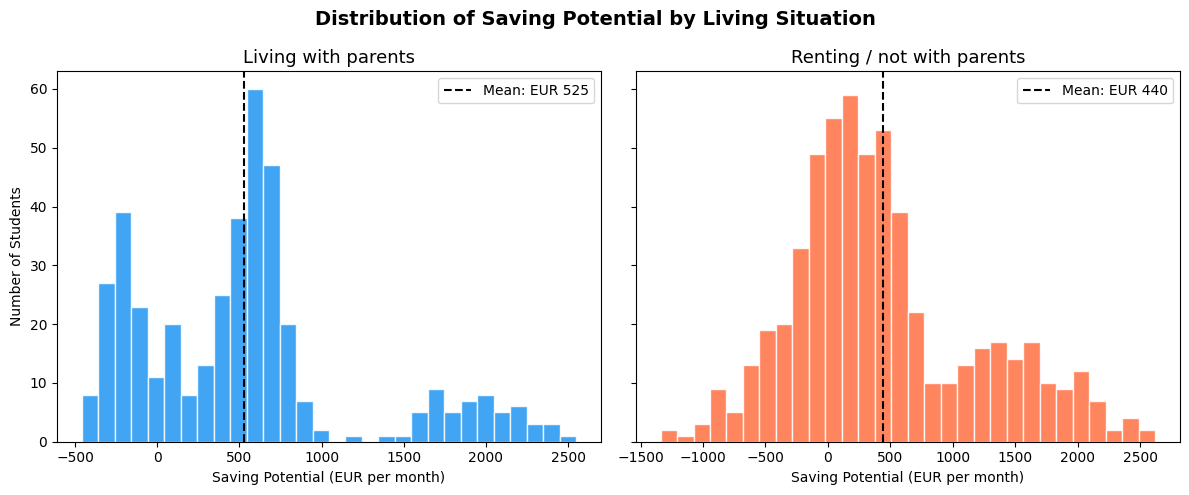

In [14]:
# 5.3 - Histogram: saving potential by living situation
# Compare the distribution of structural monthly saving capacity between students
# living with parents and those renting / living independently.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, (group, label, color) in enumerate([
    ('Yes', 'Living with parents', '#2196F3'),
    ('No', 'Renting / not with parents', '#FF7043')
]):
    data = df[df['living_with_parents'] == group]['saving_potential']
    axes[i].hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: EUR {data.mean():.0f}')
    axes[i].set_title(label, fontsize=13)
    axes[i].set_xlabel('Saving Potential (EUR per month)')
    axes[i].legend()

axes[0].set_ylabel('Number of Students')
fig.suptitle('Distribution of Saving Potential by Living Situation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


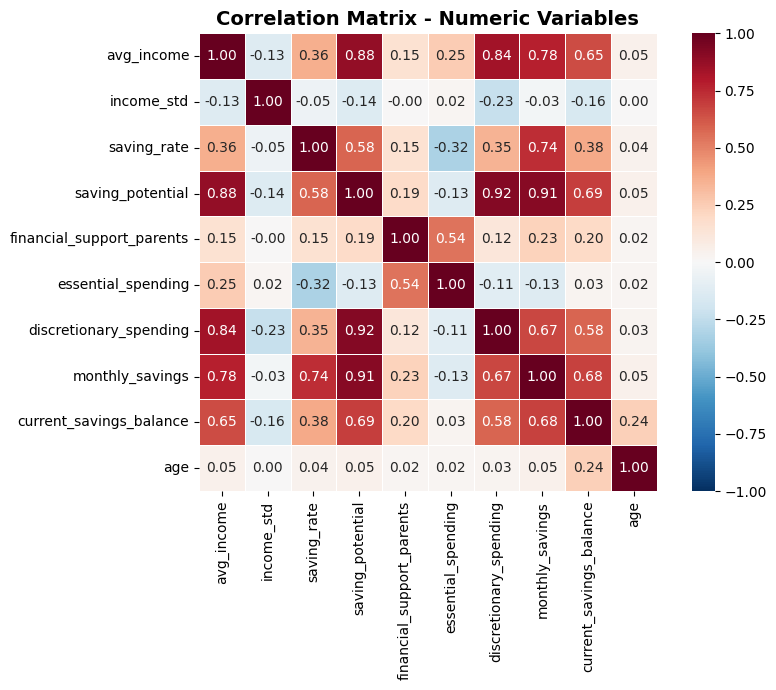

In [15]:
# 5.4 — Correlation heatmap for numeric variables
# We check pairwise correlations before regression to identify:
#   - Potential multicollinearity (r > 0.8 between predictors → inflate VIF)
#   - Tautological relationships (variables that are arithmetic components of each other)
#   - Variables that strongly correlate with our dependent variables (good predictors)
# High correlations here guide which variables to include/exclude in regression.

numeric_vars = ['avg_income', 'income_std', 'saving_rate', 'saving_potential',
                'financial_support_parents', 'essential_spending',
                'discretionary_spending', 'monthly_savings', 'current_savings_balance', 'age']

corr_matrix = df[numeric_vars].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax, fmt='.2f')
ax.set_title('Correlation Matrix - Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 — Correlation Matrix

**Purpose**: We compute pairwise Pearson correlations before building regressions to (1) understand which financial variables move together, (2) flag potential multicollinearity that could destabilise coefficient estimates, and (3) guide variable selection for our models.

**Key findings and regression implications**:

- **`saving_potential` ↔ `avg_income`** (r = 0.88) and **↔ `financial_support_parents`** — these are arithmetic components of `saving_potential`, so including them as predictors in Regression 1 would create a near-tautological model. We exclude both from the feature matrix.
- **`saving_potential` ↔ `discretionary_spending`** (r = 0.92) — students with more room to save tend to spend it on non-essentials. This motivates Regression 2, where we model discretionary spending as a function of `saving_potential` and living situation to quantify this behavioural leakage.
- **`saving_potential` ↔ `monthly_savings`** (r = 0.91) — higher potential does translate into higher absolute savings, but the equally strong link to discretionary spending shows that much of the surplus leaks away.
- **`essential_spending` ↔ `financial_support_parents`** (r = 0.54) — students with higher essential costs (likely renters) receive more parental support, partially offsetting the cost of living away from home.
- **`age`** — near-zero correlations with all financial variables (max r = 0.24), suggesting it will not be a significant predictor in either regression. We retain it as a control but do not expect significance.

**Multicollinearity note**: The high correlations among `saving_potential`, `discretionary_spending`, `monthly_savings`, and `avg_income` are expected given their arithmetic relationships. We address this in both regressions by carefully excluding variables that mechanically overlap with the dependent variable.

## Section 6: Regression 1 — What Drives Saving Potential?

We use **OLS (Ordinary Least Squares)** to model what determines a student's saving potential (total income minus essential spending). This directly tests our hypothesis: does living with parents lead to higher saving potential?

**OLS assumptions**:
1. **Linearity** — the relationship between predictors and DV is linear
2. **Independence** — observations are independent (cross-sectional survey, one response per student)
3. **Homoskedasticity** — constant residual variance (tested with White's test; if violated, we use HC3 robust standard errors)
4. **Normality of residuals** — for valid inference on small samples (with n = 977, the Central Limit Theorem provides robustness)
5. **No perfect multicollinearity** — checked via VIF (Variance Inflation Factor)

**Dependent variable**: `saving_potential` (avg_income + financial_support_parents − essential_spending)

**Independent variables**:
- `living_with_parents` (binary) — our key variable of interest
- `income_std` — income volatility (half-range between best and worst month)
- `age`
- `year_of_study`
- `sex` (dummy: Female; reference = Male)
- `employment_status` (dummies: Part-time, Freelance, Full-time; reference = Unemployed)
- `field_of_study` (dummies: Arts & Humanities, Health Sciences, STEM, Social Sciences; reference = Business)

**Excluded from predictors**:
- `avg_income`, `financial_support_parents`, `essential_spending` — direct arithmetic components of the dependent variable (`saving_potential = avg_income + financial_support_parents − essential_spending`). Including them would fit an accounting identity rather than reveal genuine drivers, inflating R² with mechanically determined coefficients.
- `saving_rate`, `monthly_savings` — both are derived from `saving_potential` (`monthly_savings = saving_potential − discretionary_spending`; `saving_rate = monthly_savings / avg_income`), so including either would create an endogenous (circular) relationship.
- `discretionary_spending` — occurs *after* saving potential is determined (it is what students do with their surplus), so it cannot be a cause of saving potential. Including it would introduce reverse causality.
- `income_highest_month`, `income_lowest_month` — replaced by the engineered `income_std`, which captures income volatility without duplicating information already embedded in `saving_potential` via `avg_income`.
- `current_savings_balance` — a cumulative stock (total saved to date), not a monthly flow driver. It reflects past behaviour rather than current predictors.

**Sample size**: n = 977 (no rows are dropped in this specification).

**Approach**:
1. Create dummy variables, drop reference categories to avoid the dummy variable trap
2. Fit OLS with `statsmodels`
3. Run White's test for heteroskedasticity
4. If heteroskedasticity detected → re-estimate with robust standard errors (HC3)
5. Check multicollinearity via VIF

In [16]:
# 6.1 — Prepare variables: create dummies and set up X (features) and y (target)
#
# OLS regression requires all inputs to be numeric. Categorical variables (like
# employment_status, sex, and field_of_study) must be converted to dummy (0/1)
# variables. We use "drop one category" encoding to avoid the dummy variable
# trap — perfect multicollinearity where the dummies sum to 1 (the constant).

# --- Employment status dummies ---
# Creates one binary column per category (e.g. emp_Part-time = 1 if Part-time, else 0)
# We drop 'Unemployed' as the reference category — all employment coefficients are
# interpreted relative to unemployed students
emp_dummies = pd.get_dummies(df['employment_status'], prefix='emp', drop_first=False, dtype=int)
emp_dummies = emp_dummies.drop(columns=['emp_Unemployed'])  # reference = Unemployed

# --- Sex dummy ---
# Drop 'Male' as reference — the sex_Female coefficient measures the difference
# in saving potential for females vs males, holding all else constant
sex_dummies = pd.get_dummies(df['sex'], prefix='sex', drop_first=False, dtype=int)
sex_dummies = sex_dummies.drop(columns=['sex_Male'])  # reference = Male

# --- Field of study dummies ---
# Drop 'Business' as reference — all field coefficients are interpreted relative
# to Business students
field_dummies = pd.get_dummies(df['field_of_study'], prefix='field', drop_first=False, dtype=int)
field_dummies = field_dummies.drop(columns=['field_Business'])  # reference = Business

# --- Living with parents binary ---
# Convert Yes/No string to 1/0 integer for regression
df['lwp_binary'] = (df['living_with_parents'] == 'Yes').astype(int)

# --- Assemble the feature matrix X ---
X = pd.concat([
    df[['lwp_binary', 'income_std', 'age', 'year_of_study']],
    sex_dummies,
    emp_dummies,
    field_dummies
], axis=1)

# --- Add constant (intercept) ---
# statsmodels does not add an intercept by default (unlike sklearn).
# The constant represents the baseline predicted value when all predictors are 0
# (i.e. the reference group: male, unemployed, renting, Business student).
X = sm.add_constant(X)

# --- Dependent variable ---
# saving_potential = avg_income + financial_support_parents - essential_spending
# This is what we want to explain/predict with the model
y = df['saving_potential']

# --- Drop rows with NaN or inf ---
# np.isfinite() returns False for both NaN and inf, so this mask removes all
# problematic rows from both X and y simultaneously to keep them aligned.
mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X = X[mask]
y = y[mask]

print(f"Rows dropped (NaN/inf): {(~mask).sum()}")
print(f"Feature matrix shape: {X.shape}")
print(f"Features: {list(X.columns)}")

Rows dropped (NaN/inf): 0
Feature matrix shape: (977, 13)
Features: ['const', 'lwp_binary', 'income_std', 'age', 'year_of_study', 'sex_Female', 'emp_Freelance', 'emp_Full-time', 'emp_Part-time', 'field_Arts & Humanities', 'field_Health Sciences', 'field_STEM', 'field_Social Sciences']


In [17]:
# 6.2 — Fit OLS (Ordinary Least Squares) model and display summary
#
# OLS minimises the sum of squared residuals (differences between observed and
# predicted values of saving_potential). It finds the linear combination of
# predictors that best fits the data.
#
# The .fit() method estimates the coefficients (betas) and computes standard errors,
# t-statistics, p-values, R², and other diagnostics.
# The .summary() output shows:
#   - Coefficient estimates and their significance (p-values)
#   - R² (proportion of variance explained) and Adjusted R² (penalised for # of predictors)
#   - F-statistic (overall model significance)
#   - Durbin-Watson statistic (tests for autocorrelation in residuals)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       saving_potential   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     367.5
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:26:43   Log-Likelihood:                -6967.1
No. Observations:                 977   AIC:                         1.396e+04
Df Residuals:                     964   BIC:                         1.402e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    -

In [18]:
# 6.3 — Diagnostics: White's test for heteroskedasticity + VIF for multicollinearity
#
# Two key assumptions of OLS must be checked before trusting the standard errors:
# 1. Homoskedasticity — the variance of residuals should be constant across all
#    levels of the predictors. If it varies (heteroskedasticity), standard errors
#    are biased, making t-tests and p-values unreliable.
# 2. No severe multicollinearity — predictors should not be too highly correlated
#    with each other. If they are, individual coefficient estimates become unstable.

# --- White's test ---
# H0: residuals are homoskedastic (constant variance)
# H1: residuals are heteroskedastic (variance depends on predictors)
# If p-value < 0.05 → reject H0 → heteroskedasticity present → need robust SEs
white_test = het_white(model.resid, model.model.exog)
labels = ['Test Statistic', 'p-value (White)', 'F-statistic', 'F p-value']
print("=== White's Test for Heteroskedasticity ===")
for label, val in zip(labels, white_test):
    print(f"  {label}: {val:.4f}")

if white_test[1] < 0.05:
    print("\n  → p < 0.05: heteroskedasticity detected. We will re-estimate with robust SEs (HC3).")
else:
    print("\n  → p > 0.05: no evidence of heteroskedasticity.")

# --- VIF (Variance Inflation Factor) ---
# VIF measures how much the variance of a coefficient is inflated due to correlation
# with other predictors. Calculated as: VIF_j = 1 / (1 - R²_j), where R²_j is
# the R-squared from regressing predictor j on all other predictors.
# Rule of thumb:
#   VIF < 5  → no concern
#   VIF 5-10 → moderate, worth monitoring
#   VIF > 10 → problematic multicollinearity, coefficient may be unreliable
print("\n=== Variance Inflation Factors (VIF) ===")
vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
# Exclude constant from display (its VIF is not meaningful)
print(vif_data[vif_data['Variable'] != 'const'].to_string(index=False))

=== White's Test for Heteroskedasticity ===
  Test Statistic: 242.6743
  p-value (White): 0.0000
  F-statistic: 4.1493
  F p-value: 0.0000

  → p < 0.05: heteroskedasticity detected. We will re-estimate with robust SEs (HC3).

=== Variance Inflation Factors (VIF) ===
               Variable      VIF
             lwp_binary 1.107321
             income_std 4.260711
                    age 2.071253
          year_of_study 2.069157
             sex_Female 1.006760
          emp_Freelance 4.934977
          emp_Full-time 1.771213
          emp_Part-time 2.154752
field_Arts & Humanities 1.463608
  field_Health Sciences 1.327754
             field_STEM 1.487469
  field_Social Sciences 1.317326


In [19]:
# 6.4 — Re-estimate with robust standard errors (HC3)
#
# Since White's test confirmed heteroskedasticity, the standard OLS standard errors
# are unreliable. We re-estimate using HC3 (Heteroskedasticity-Consistent) standard errors.
#
# Key points:
# - The coefficient estimates (betas) do NOT change — they are still OLS estimates
# - Only the standard errors change → which affects t-statistics, p-values, and
#   confidence intervals
# - HC3 applies a leverage-based correction: observations with high leverage (unusual
#   predictor values) get larger corrections, making HC3 more conservative than HC0/HC1
# - HC3 is preferred for smaller samples as it avoids underestimating standard errors
#
# cov_type='HC3' tells statsmodels to use the MacKinnon & White (1985) HC3 estimator

model_robust = sm.OLS(y, X).fit(cov_type='HC3')
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:       saving_potential   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     329.8
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:26:43   Log-Likelihood:                -6967.1
No. Observations:                 977   AIC:                         1.396e+04
Df Residuals:                     964   BIC:                         1.402e+04
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    -

### Regression 1 — Interpretation

**Model fit**: R² = 0.821 (Adj. R² = 0.818), meaning our model explains 82.1% of the variation in saving potential using demographic and behavioural predictors. 

**Key coefficients** (from the HC3 robust model, n = 977):

| Variable | Coefficient | p-value | Interpretation |
|---|---|---|---|
| **`lwp_binary`** | **+381.32** | **< 0.001** | Students living at home have ~€381 higher saving potential than renters, holding all else constant. This confirms the core hypothesis — living at home provides a substantial structural advantage through lower essential spending (no rent). |
| **`income_std`** | +0.66 | < 0.001 | Each €1 increase in income volatility (half-range between best and worst month) adds €0.66 to saving potential. |
| **`age`** | +1.37 | 0.890 | **Not significant.** Age has no meaningful effect on saving potential once employment and living situation are controlled for. |
| **`year_of_study`** | −0.40 | 0.978 | **Not significant.** Academic progression does not affect saving potential. |
| **`sex_Female`** | +19.85 | 0.311 | **Not significant.** No statistically significant gender difference in saving potential. |
| **`emp_Freelance`** | **+365.70** | **< 0.001** | Freelancers have ~€366 higher saving potential than unemployed students (the reference), reflecting their earning capacity despite income volatility. |
| **`emp_Full-time`** | **+2,097.86** | **< 0.001** | Full-time workers have ~€2,098 higher saving potential than unemployed students — by far the largest coefficient. |
| **`emp_Part-time`** | **+616.70** | **< 0.001** | Part-time workers have ~€617 higher saving potential than unemployed students, a significant income advantage. |
| **`field_Arts & Humanities`** | −73.33 | 0.009 | Arts & Humanities students have ~€73 lower saving potential than Business students (the reference). |
| **`field_Health Sciences`** | −57.98 | 0.109 | **Not significant.** No statistically significant difference from Business students. |
| **`field_STEM`** | −16.37 | 0.535 | **Not significant.** No statistically significant difference from Business students. |
| **`field_Social Sciences`** | **−94.42** | **0.009** | Social Sciences students have ~€94 lower saving potential than Business students — the largest field effect. |

**Diagnostics**:

- **White's test** (p ≈ 0.000): Highly significant — heteroskedasticity is present. The standard OLS standard errors are unreliable, confirming the need for HC3 robust standard errors. The HC3 model keeps the same coefficients but adjusts standard errors (and therefore p-values) to account for non-constant residual variance.
- **VIF**: All predictors have VIF below 5:
  - `lwp_binary`: 1.11 — no concern
  - `income_std`: 4.26 — moderate, acceptable
  - `emp_Freelance`: 4.93 — moderate, acceptable
  - `age`: 2.07, `year_of_study`: 2.07 — no concern (mild correlation between the two is expected)
  - `emp_Part-time`: 2.15, `emp_Full-time`: 1.77 — no concern
  - All field dummies below 1.49 — no concern
  - `sex_Female`: 1.01 — no concern

**Implication for StepStone**: The three dominant predictors of saving potential are employment status (`emp_Full-time` = +€2,098), living situation (`lwp_binary` = +€381), and field of study (Social Sciences = −€94, Arts & Humanities = −€73 vs Business). Students living at home with part-time or full-time work are best positioned to save. The app should target at-home students and employed students and help them convert this structural advantage into actual savings.

## Section 7: Regression 2 — What Drives Discretionary Spending?

Regression 1 established that living with parents increases saving potential by ~€381, while employment status is the strongest driver overall (full-time workers gain +€2,098 and part-time workers +€617 compared to unemployed students). But do at-home and employed students actually save this advantage, or do they spend it on non-essentials? This second regression tests the **spending side** of our hypothesis by modelling discretionary spending.

**Dependent variable**: `discretionary_spending`

**Independent variables**:
- `living_with_parents` (binary)
- `saving_potential` — the available budget after essential costs; this directly determines how much a student *can* spend on non-essentials. Unlike in Regression 1, there is **no tautological concern** here because `discretionary_spending` is not a component of `saving_potential`
- `income_std` — income volatility
- `age`
- `year_of_study`
- `sex` (dummy: Female; reference = Male)
- `employment_status` (dummies: Part-time, Freelance, Full-time; reference = Unemployed)
- `field_of_study` (dummies: Arts & Humanities, Health Sciences, STEM, Social Sciences; reference = Business)

**Excluded from predictors**:
- `saving_rate`, `monthly_savings` — both are derived from `saving_potential` and `discretionary_spending` (`monthly_savings = saving_potential − discretionary_spending`; `saving_rate = monthly_savings / avg_income`). Including either would create an endogenous (circular) relationship — the predictor would already contain the dependent variable, biasing the estimates.
- `avg_income`, `financial_support_parents`, `essential_spending` — direct arithmetic components of `saving_potential`, which is already included as a predictor. Adding them would introduce severe multicollinearity without additional explanatory value.
- `income_highest_month`, `income_lowest_month` — replaced by the engineered `income_std`.
- `current_savings_balance` — a cumulative stock (total saved to date), not a driver of current monthly spending.

**Sample size**: n = 977 (no rows are dropped in this model).

**Approach**: Same diagnostic workflow as Regression 1 — OLS → White's test → VIF → HC3 if needed.

In [20]:
# 7.1 — Prepare variables for Regression 2: X2 (features) and y2 (target)
#
# We reuse the dummy variables created in Section 6 (emp_dummies, sex_dummies,
# field_dummies, lwp_binary).
#
# The key difference from Regression 1 is:
#   - DV is now discretionary_spending (not saving_potential)
#   - We INCLUDE saving_potential as a predictor — it represents how much budget
#     a student has available for discretionary spending. This is NOT tautological
#     because discretionary_spending is not part of the saving_potential formula.

# --- Assemble the feature matrix X2 ---
X2 = pd.concat([
    df[['lwp_binary', 'saving_potential', 'income_std', 'age', 'year_of_study']],
    sex_dummies,
    emp_dummies,
    field_dummies
], axis=1)

# Add constant (intercept) for OLS — represents expected discretionary spending
# for the reference group: male, unemployed, renting, Business student
X2 = sm.add_constant(X2)

# --- Dependent variable ---
# discretionary_spending: the amount students spend on non-essential items per month
y2 = df['discretionary_spending']

# --- Drop rows with NaN or inf ---
mask2 = np.isfinite(X2).all(axis=1) & np.isfinite(y2)
X2 = X2[mask2]
y2 = y2[mask2]

print(f"Rows dropped (NaN/inf): {(~mask2).sum()}")
print(f"Feature matrix shape: {X2.shape}")
print(f"Features: {list(X2.columns)}")

Rows dropped (NaN/inf): 0
Feature matrix shape: (977, 14)
Features: ['const', 'lwp_binary', 'saving_potential', 'income_std', 'age', 'year_of_study', 'sex_Female', 'emp_Freelance', 'emp_Full-time', 'emp_Part-time', 'field_Arts & Humanities', 'field_Health Sciences', 'field_STEM', 'field_Social Sciences']


In [21]:
# 7.2 — Fit OLS model for discretionary spending


model2 = sm.OLS(y2, X2).fit()
print(model2.summary())

                              OLS Regression Results                              
Dep. Variable:     discretionary_spending   R-squared:                       0.867
Model:                                OLS   Adj. R-squared:                  0.865
Method:                     Least Squares   F-statistic:                     482.9
Date:                    Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                            13:26:44   Log-Likelihood:                -6256.4
No. Observations:                     977   AIC:                         1.254e+04
Df Residuals:                         963   BIC:                         1.261e+04
Df Model:                              13                                         
Covariance Type:                nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [22]:
# 7.3 — Diagnostics: White's test for heteroskedasticity + VIF for multicollinearity
#
# Same diagnostic checks as Regression 1:
# - White's test checks if residual variance is constant (homoskedasticity assumption)
# - VIF checks if predictors are too correlated with each other (multicollinearity)
# If White's test is significant → we need HC3 robust standard errors

# --- White's test ---
white_test2 = het_white(model2.resid, model2.model.exog)
labels = ['Test Statistic', 'p-value (White)', 'F-statistic', 'F p-value']
print("=== White's Test for Heteroskedasticity ===")
for label, val in zip(labels, white_test2):
    print(f"  {label}: {val:.4f}")

if white_test2[1] < 0.05:
    print("\n  → p < 0.05: heteroskedasticity detected. We will re-estimate with robust SEs (HC3).")
else:
    print("\n  → p > 0.05: no evidence of heteroskedasticity.")

# --- VIF ---
print("\n=== Variance Inflation Factors (VIF) ===")
vif_data2 = pd.DataFrame({
    'Variable': X2.columns,
    'VIF': [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]
})
print(vif_data2[vif_data2['Variable'] != 'const'].to_string(index=False))

=== White's Test for Heteroskedasticity ===
  Test Statistic: 338.6557
  p-value (White): 0.0000
  F-statistic: 5.4903
  F p-value: 0.0000

  → p < 0.05: heteroskedasticity detected. We will re-estimate with robust SEs (HC3).

=== Variance Inflation Factors (VIF) ===
               Variable      VIF
             lwp_binary 1.492293
       saving_potential 5.574795
             income_std 4.532931
                    age 2.071325
          year_of_study 2.069159
             sex_Female 1.007836
          emp_Freelance 5.140064
          emp_Full-time 9.151839
          emp_Part-time 3.178118
field_Arts & Humanities 1.473556
  field_Health Sciences 1.332018
             field_STEM 1.488033
  field_Social Sciences 1.328194


In [23]:
# 7.4 — Re-estimate with robust standard errors (HC3)
#
# White's test confirmed heteroskedasticity (p ≈ 0.000), so the standard OLS
# standard errors are unreliable. We re-estimate with HC3 robust standard errors.

model2_robust = sm.OLS(y2, X2).fit(cov_type='HC3')
print(model2_robust.summary())

                              OLS Regression Results                              
Dep. Variable:     discretionary_spending   R-squared:                       0.867
Model:                                OLS   Adj. R-squared:                  0.865
Method:                     Least Squares   F-statistic:                     174.4
Date:                    Mon, 06 Apr 2026   Prob (F-statistic):          2.25e-242
Time:                            13:26:44   Log-Likelihood:                -6256.4
No. Observations:                     977   AIC:                         1.254e+04
Df Residuals:                         963   BIC:                         1.261e+04
Df Model:                              13                                         
Covariance Type:                      HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

### Regression 2 — Interpretation

**Model fit**: R² = 0.867 (Adj. R² = 0.865), meaning our model explains 86.7% of the variation in discretionary spending. This is a strong fit — the available budget (`saving_potential`) and employment status are powerful predictors of how much students spend on non-essentials.

**Key coefficients** (from the HC3 robust model, n = 977):

| Variable | Coefficient | p-value | Interpretation |
|---|---|---|---|
| **`lwp_binary`** | **+43.07** | **0.002** | Students living at home spend ~€43 more per month on discretionary items than renters, *even after controlling for their available budget*. |
| **`saving_potential`** | +0.43 | < 0.001 | For every additional €1 of available budget (income + support − essentials), students spend €0.43 on discretionary items. This means 43% of any budget increase goes to non-essentials rather than savings — a strong marginal propensity to consume. |
| **`income_std`** | −0.15 | < 0.001 | Students with more volatile income spend slightly less on discretionary items. Income uncertainty appears to encourage more cautious spending — a rational response to unpredictable earnings. |
| **`age`** | −2.02 | 0.594 | **Not significant.** Age does not affect discretionary spending once budget and employment are controlled for. |
| **`year_of_study`** | −0.13 | 0.983 | **Not significant.** Academic progression has no effect on discretionary spending. |
| **`sex_Female`** | +12.36 | 0.196 | **Not significant.** No statistically significant gender difference in discretionary spending. |
| **`emp_Freelance`** | +50.37 | 0.022 | Freelancers spend ~€50 more on discretionary items than unemployed students, beyond what their higher saving potential already explains. |
| **`emp_Full-time`** | **+162.70** | **0.001** | Full-time workers spend ~€163 more on discretionary items than unemployed students, the largest effect. |
| **`emp_Part-time`** | −22.23 | 0.193 | **Not significant.** Part-time workers do not spend significantly differently from unemployed students on discretionary items, once budget is controlled for. |
| **`field_Arts & Humanities`** | −27.36 | 0.040 | Arts & Humanities students spend ~€27 less on discretionary items than Business students. |
| **`field_Health Sciences`** | +6.40 | 0.717 | **Not significant.** No difference from Business students. |
| **`field_STEM`** | −13.99 | 0.287 | **Not significant.** No difference from Business students. |
| **`field_Social Sciences`** | −12.40 | 0.422 | **Not significant.** No difference from Business students despite having significantly lower saving potential in Regression 1 (−€94). |

**Diagnostics**:

- **White's test** (p ≈ 0.000): Heteroskedasticity confirmed — HC3 robust standard errors are necessary and used above.
- **VIF**: All predictors have VIF below 10:
  - `lwp_binary`: 1.49 — no concern
  - `saving_potential`: 5.57 — moderate, acceptable 
  - `income_std`: 4.53 — moderate, acceptable
  - `emp_Freelance`: 5.14 — moderate, acceptable
  - `emp_Full-time`: 9.15 — approaching the threshold but acceptable
  - `age`: 2.07, `year_of_study`: 2.07 — no concern
  - `emp_Part-time`: 3.18 — no concern
  - All field dummies below 1.49 — no concern
  - `sex_Female`: 1.01 — no concern

**Connecting Regression 1 and 2 — the StepStone opportunity**:

Regression 1 showed that at-home students have €381 more saving potential than renters. Regression 2 shows they spend €43 more on discretionary items, even after controlling for that budget advantage. At the same time, full-time employees have both high saving potential (+€2,098) and high discretionary spending (+€163), suggesting that higher earnings lead to higher consumption rather than proportionally higher savings. Finally, for every additional euro of available budget, students spend 43 cents on discretionary items rather than saving it.

This shows that there is strong potential for StepStone to improve the financial habits of students who have the means to save more, and help them achieve their major financial goals sooner.

## Section 8: Time Series Forecasting — Irish House Prices

To estimate when a student can afford a mortgage deposit, we need to forecast future house prices. We use the **CSO Residential Property Price Index (RPPI)** — an official monthly index published by the Central Statistics Office of Ireland (base year 2015 = 100).

**Data source**: CSO Table HPM09 — National residential property price index, January 2005 to December 2025 (252 monthly observations).

**Methodology**:
1. **Data preparation** — load, filter, and parse the CSO data
2. **Stationarity testing** — ADF test to check if the series has a unit root
3. **ACF & PACF analysis** — identify candidate AR and MA orders
4. **Model selection** — grid search across ARMA orders using AIC/BIC information criteria
5. **ARIMA estimation** — fit the optimal model and check diagnostics (Ljung-Box, Jarque-Bera)
6. **Train/test split & forecasting** — evaluate static vs dynamic out-of-sample forecasts
7. **Forecast evaluation** — RMSE, MAE, MAPE to quantify prediction accuracy
8. **Future projection** — forecast house prices 5 years ahead for the business case

Series: 2005-01 to 2025-12
Observations: 252
Index range: 73.4 to 204.6
Latest value: 204.6 (base 2015 = 100)


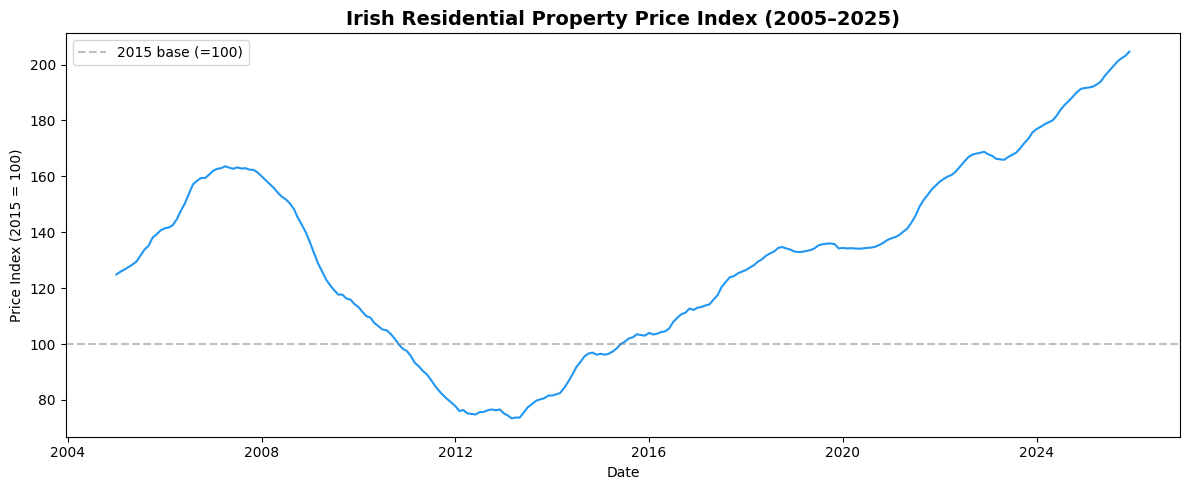

In [24]:
# 8.1 — Load and prepare the CSO Residential Property Price Index
#
# The raw CSV from the CSO contains multiple property types (national, Dublin,
# apartments, houses, regional) and multiple statistics per type (price index,
# 1-month change, 3-month change, 12-month change).
# We filter to:
#   - STATISTIC == 'HPM09C01' → the actual price index (not percentage changes)
#   - Type == 'National - all residential properties' → broadest coverage
#
# The TLIST(M1) column contains dates in YYYYMM format (e.g. '200501' = Jan 2005).
# We parse this to a proper datetime index for time series analysis.

raw_hp = pd.read_csv('data/HPM09.20260307T190315.csv')

# Filter to national price index only
hp = raw_hp[
    (raw_hp['STATISTIC'] == 'HPM09C01') &
    (raw_hp['Type of Residential Property'] == 'National - all residential properties')
].copy()

# Parse date column and convert index values to float
hp['date'] = pd.to_datetime(hp['TLIST(M1)'], format='%Y%m')
hp['price_index'] = pd.to_numeric(hp['VALUE'], errors='coerce')

# Set date as index and keep only the price index column
hp = hp.set_index('date').sort_index()[['price_index']].dropna()

# Set frequency to month-start (required by statsmodels for ARIMA)
hp.index.freq = 'MS'

print(f"Series: {hp.index[0].strftime('%Y-%m')} to {hp.index[-1].strftime('%Y-%m')}")
print(f"Observations: {len(hp)}")
print(f"Index range: {hp['price_index'].min():.1f} to {hp['price_index'].max():.1f}")
print(f"Latest value: {hp['price_index'].iloc[-1]:.1f} (base 2015 = 100)")

# Plot the raw series
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hp.index, hp['price_index'], color='#2196F3', linewidth=1.5)
ax.axhline(y=100, color='grey', linestyle='--', alpha=0.5, label='2015 base (=100)')
ax.set_xlabel('Date')
ax.set_ylabel('Price Index (2015 = 100)')
ax.set_title('Irish Residential Property Price Index (2005–2025)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

=== ADF Test on Raw Price Index ===
  Test statistic: -1.4722
  p-value:        0.5472
  Lags used:      9
  Critical values: {'1%': np.float64(-3.457664132155201), '5%': np.float64(-2.8735585105960224), '10%': np.float64(-2.5731749894132916)}
  → p > 0.05: FAIL to reject H0 — series is NON-STATIONARY (has unit root)

=== ADF Test on First-Differenced Series (% change) ===
  Test statistic: -1.7744
  p-value:        0.3933
  Lags used:      8
  → p > 0.05: FAIL to reject H0 — first difference is STILL NON-STATIONARY
  → One round of differencing is not enough. We need d = 2.

=== ADF Test on Second-Differenced Series ===
  Test statistic: -9.6397
  p-value:        0.0000
  Lags used:      7
  → p < 0.05: reject H0 — second-differenced series is STATIONARY
  → We will use d = 2 in our ARIMA model.


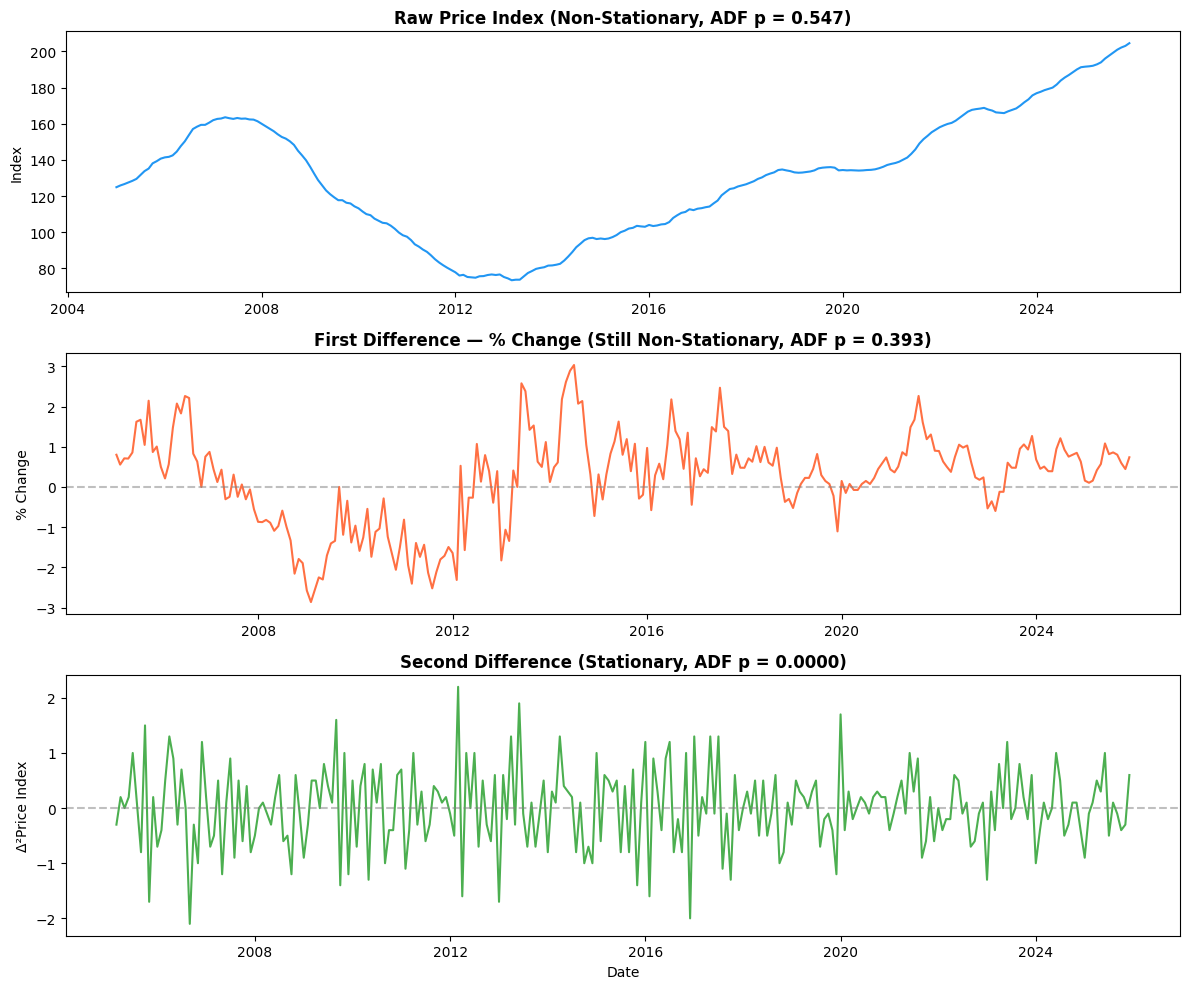

In [25]:
# 8.2 — Stationarity testing with the Augmented Dickey-Fuller (ADF) test
#
# ARIMA models require the series to be stationary (constant mean and variance
# over time). The ADF test checks for a unit root:
#   H0: The series has a unit root (non-stationary)
#   H1: The series is stationary
#   If p-value < 0.05 → reject H0 → series is stationary
#   If p-value > 0.05 → fail to reject H0 → non-stationary → needs differencing
#
# We progressively difference until the ADF test confirms stationarity.

# --- ADF on raw series ---
adf_raw = st.adfuller(hp['price_index'], autolag='AIC')
print("=== ADF Test on Raw Price Index ===")
print(f"  Test statistic: {adf_raw[0]:.4f}")
print(f"  p-value:        {adf_raw[1]:.4f}")
print(f"  Lags used:      {adf_raw[2]}")
print(f"  Critical values: {adf_raw[4]}")
if adf_raw[1] > 0.05:
    print("  → p > 0.05: FAIL to reject H0 — series is NON-STATIONARY (has unit root)")
else:
    print("  → p < 0.05: reject H0 — series is stationary")

# --- First difference (percentage change) ---
hp['dhp'] = hp['price_index'].pct_change() * 100
hp_diff1 = hp['dhp'].dropna()

adf_diff1 = st.adfuller(hp_diff1, autolag='AIC')
print("\n=== ADF Test on First-Differenced Series (% change) ===")
print(f"  Test statistic: {adf_diff1[0]:.4f}")
print(f"  p-value:        {adf_diff1[1]:.4f}")
print(f"  Lags used:      {adf_diff1[2]}")
if adf_diff1[1] > 0.05:
    print("  → p > 0.05: FAIL to reject H0 — first difference is STILL NON-STATIONARY")
    print("  → One round of differencing is not enough. We need d = 2.")
else:
    print("  → p < 0.05: reject H0 — first-differenced series is stationary")

# --- Second difference ---
# Since the first difference is not stationary, we difference again.
# This is what ARIMA with d=2 does internally on the raw levels.
hp_diff2 = hp['price_index'].diff().diff().dropna()

adf_diff2 = st.adfuller(hp_diff2, autolag='AIC')
print("\n=== ADF Test on Second-Differenced Series ===")
print(f"  Test statistic: {adf_diff2[0]:.4f}")
print(f"  p-value:        {adf_diff2[1]:.4f}")
print(f"  Lags used:      {adf_diff2[2]}")
if adf_diff2[1] > 0.05:
    print("  → p > 0.05: FAIL to reject H0 — still non-stationary")
else:
    print("  → p < 0.05: reject H0 — second-differenced series is STATIONARY")
    print("  → We will use d = 2 in our ARIMA model.")

# Plot all three series
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(hp.index, hp['price_index'], color='#2196F3')
axes[0].set_title('Raw Price Index (Non-Stationary, ADF p = {:.3f})'.format(adf_raw[1]),
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Index')

axes[1].plot(hp_diff1.index, hp_diff1, color='#FF7043')
axes[1].axhline(y=0, color='grey', linestyle='--', alpha=0.5)
axes[1].set_title('First Difference — % Change (Still Non-Stationary, ADF p = {:.3f})'.format(adf_diff1[1]),
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('% Change')

axes[2].plot(hp_diff2.index, hp_diff2, color='#4CAF50')
axes[2].axhline(y=0, color='grey', linestyle='--', alpha=0.5)
axes[2].set_title('Second Difference (Stationary, ADF p = {:.4f})'.format(adf_diff2[1]),
                   fontsize=12, fontweight='bold')
axes[2].set_ylabel('Δ²Price Index')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

Correlogram (ACF & PACF for lags 1–12, second-differenced series):

       ACF   PACF
Lag              
1   -0.328 -0.329
2    0.191  0.095
3   -0.108 -0.023
4   -0.008 -0.074
5   -0.149 -0.182
6   -0.070 -0.184
7   -0.052 -0.117
8   -0.128 -0.219
9    0.152  0.022
10   0.039  0.096
11   0.019 -0.043
12   0.116  0.058


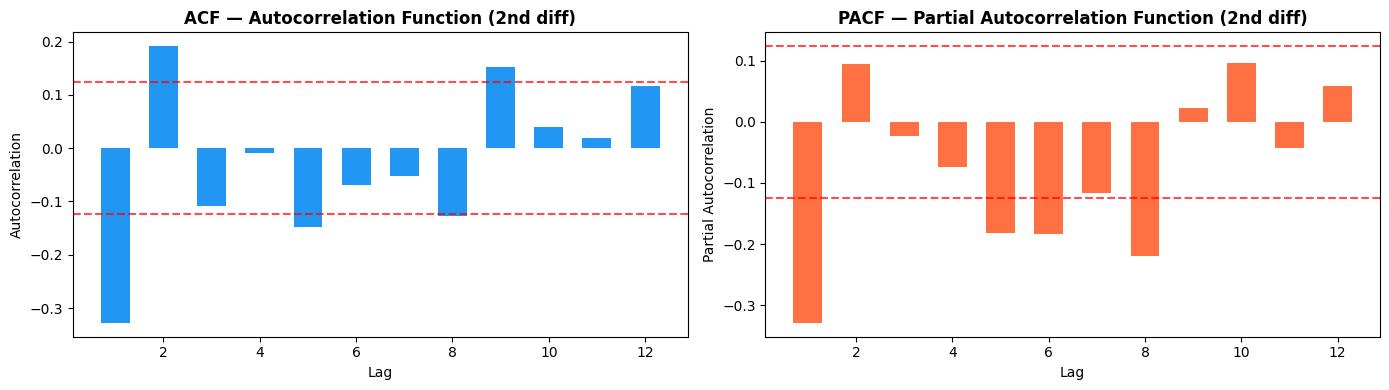

In [26]:
# 8.3 — ACF & PACF analysis (Autocorrelation and Partial Autocorrelation)
#
# ACF and PACF help identify the order of ARMA components:
#   - ACF (Autocorrelation Function): measures correlation between the series
#     and its lagged values. A sharp cutoff after lag q suggests an MA(q) process.
#   - PACF (Partial ACF): measures correlation at lag k after removing the effect
#     of intermediate lags. A sharp cutoff after lag p suggests an AR(p) process.
#
# We compute these on the SECOND-differenced series, since this is the series
# confirmed as stationary by the ADF test. ACF/PACF are only meaningful for
# stationary data — running them on a non-stationary series produces misleading
# results (e.g. slow ACF decay that mimics high-order AR).

acf_vals = smt.acf(hp_diff2, nlags=12)
pacf_vals = smt.pacf(hp_diff2, nlags=12)

# Display as a correlogram table
correlogram = pd.DataFrame({
    'Lag': range(1, 13),
    'ACF': acf_vals[1:],
    'PACF': pacf_vals[1:]
}).set_index('Lag').round(3)
print("Correlogram (ACF & PACF for lags 1–12, second-differenced series):\n")
print(correlogram)

# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF plot
axes[0].bar(range(1, 13), acf_vals[1:], color='#2196F3', width=0.6)
axes[0].axhline(y=1.96/np.sqrt(len(hp_diff2)), color='red', linestyle='--', alpha=0.7)
axes[0].axhline(y=-1.96/np.sqrt(len(hp_diff2)), color='red', linestyle='--', alpha=0.7)
axes[0].set_title('ACF — Autocorrelation Function (2nd diff)', fontweight='bold')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')

# PACF plot
axes[1].bar(range(1, 13), pacf_vals[1:], color='#FF7043', width=0.6)
axes[1].axhline(y=1.96/np.sqrt(len(hp_diff2)), color='red', linestyle='--', alpha=0.7)
axes[1].axhline(y=-1.96/np.sqrt(len(hp_diff2)), color='red', linestyle='--', alpha=0.7)
axes[1].set_title('PACF — Partial Autocorrelation Function (2nd diff)', fontweight='bold')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

In [27]:
# 8.4 — Model selection: grid search over ARMA orders using AIC and BIC
#
# We use an automated grid search to find the optimal AR(p) and MA(q) orders
# for the stationary (second-differenced) series.
#
# arma_order_select_ic tests all combinations of p = 0..5 and q = 0..5 and returns
# the (p, q) pair that minimises each information criterion:
#   - AIC (Akaike Information Criterion): balances fit and complexity, tends to
#     select slightly larger models. AIC = -2*log(L) + 2*k
#   - BIC (Bayesian Information Criterion): penalises complexity more heavily,
#     tends to select more parsimonious models. BIC = -2*log(L) + k*log(n)
# where L = likelihood, k = number of parameters, n = sample size.
#
# The grid search runs on the second-differenced series (confirmed stationary).
# Many complex combinations will fail to converge — this is expected and harmless;
# the grid search tries every combination and discards the ones that don't work.
#
# After identifying the BIC-optimal order, we verify that the corresponding
# ARIMA model converges when fitted on the TRAINING data (not the full dataset),
# because that is the data the model will actually be trained on in cell 8.5.
# If the BIC-optimal model does not converge on the training set, we fall back
# to the next-best BIC model that does — a non-converged model has unreliable
# parameter estimates and cannot be trusted for forecasting.

res_grid = smt.arma_order_select_ic(hp_diff2, max_ar=5, max_ma=5, ic=['aic', 'bic'])

print("=== Optimal ARMA Orders (on second-differenced series) ===")
print(f"  AIC optimal order: AR({int(res_grid.aic_min_order[0])}), MA({int(res_grid.aic_min_order[1])})")
print(f"  BIC optimal order: AR({int(res_grid.bic_min_order[0])}), MA({int(res_grid.bic_min_order[1])})")

# --- Convergence check on training data ---
# We use the same train/test split as cell 8.5 (last 24 months held out).
# This ensures the model we select actually converges when trained, not just
# when fitted on the full dataset (which has 24 more observations and may
# converge where the training subset does not).
split_idx = len(hp) - 24
train_check = hp['price_index'].iloc[:split_idx]

bic_table = res_grid.bic
bic_ranked = (
    bic_table.stack()
    .reset_index()
    .rename(columns={'level_0': 'p', 'level_1': 'q', 0: 'BIC'})
    .sort_values('BIC')
)

arima_order = None
bic_optimal = (int(res_grid.bic_min_order[0]), 2, int(res_grid.bic_min_order[1]))

for _, row in bic_ranked.iterrows():
    p, q = int(row['p']), int(row['q'])
    candidate = (p, 2, q)
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            test_fit = smt.ARIMA(train_check, order=candidate).fit()
        if test_fit.mle_retvals['converged']:
            arima_order = candidate
            if candidate == bic_optimal:
                print(f"\n  BIC-optimal ARIMA{bic_optimal} converges on training data.")
            else:
                print(f"\n  BIC-optimal ARIMA{bic_optimal} does not converge on training data.")
                print(f"  → Falling back to best converging model: ARIMA{candidate}")
            break
    except Exception:
        continue

print(f"\n  Selected model: ARIMA{arima_order}")

c:\Users\uzivatel\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\uzivatel\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\uzivatel\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\uzivatel\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_re

=== Optimal ARMA Orders (on second-differenced series) ===
  AIC optimal order: AR(5), MA(4)
  BIC optimal order: AR(3), MA(2)

  BIC-optimal ARIMA(3, 2, 2) does not converge on training data.
  → Falling back to best converging model: ARIMA(2, 2, 4)

  Selected model: ARIMA(2, 2, 4)


In [28]:
# 8.5 — Train/test split and fit ARIMA model
#
# We hold out the last 24 months (2 years) as a test set to evaluate forecast
# accuracy. The model is trained on all data before that period.
#
# ARIMA(p, d, q) on the price index levels:
#   - p = AR order (autoregressive: uses past values to predict current)
#   - d = 2 (differencing order: the model internally differences twice to
#     achieve stationarity, as confirmed by the ADF tests in cell 8.2)
#   - q = MA order (moving average: uses past forecast errors to adjust predictions)
#
# Why we use ARIMA(p, 2, q) on levels rather than manual differencing with d=0:
# When the series requires two rounds of differencing, working on levels with d=2
# keeps the pipeline cleaner — the model handles both differencings internally and
# produces forecasts directly in price index units, which simplifies the business
# case in Section 9 (no need to manually invert two layers of differencing).
#
# The summary output includes key diagnostics:
#   - Ljung-Box (Q): tests if residuals are white noise (want p > 0.05)
#   - Jarque-Bera (JB): tests if residuals are normally distributed (want p > 0.05)
#   - Heteroskedasticity (H): tests if residual variance is constant (want p > 0.05)

# --- Train/test split ---
split_idx = len(hp) - 24
train = hp['price_index'].iloc[:split_idx]
test = hp['price_index'].iloc[split_idx:]

print(f"Train set: {train.index[0].strftime('%Y-%m')} to {train.index[-1].strftime('%Y-%m')} ({len(train)} obs)")
print(f"Test set:  {test.index[0].strftime('%Y-%m')} to {test.index[-1].strftime('%Y-%m')} ({len(test)} obs)")

# --- Fit ARIMA on training data ---
print(f"\nFitting ARIMA{arima_order} on training data...\n")
model_ts = smt.ARIMA(train, order=arima_order).fit()
print(model_ts.summary())

Train set: 2005-01 to 2023-12 (228 obs)
Test set:  2024-01 to 2025-12 (24 obs)

Fitting ARIMA(2, 2, 4) on training data...

                               SARIMAX Results                                
Dep. Variable:            price_index   No. Observations:                  228
Model:                 ARIMA(2, 2, 4)   Log Likelihood                -229.959
Date:                Mon, 06 Apr 2026   AIC                            473.917
Time:                        13:26:56   BIC                            497.861
Sample:                    01-01-2005   HQIC                           483.580
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0004      1.849     -0.000      1.000      -3.624       3.624
ar.L2  

c:\Users\uzivatel\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\uzivatel\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\uzivatel\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\uzivatel\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Like

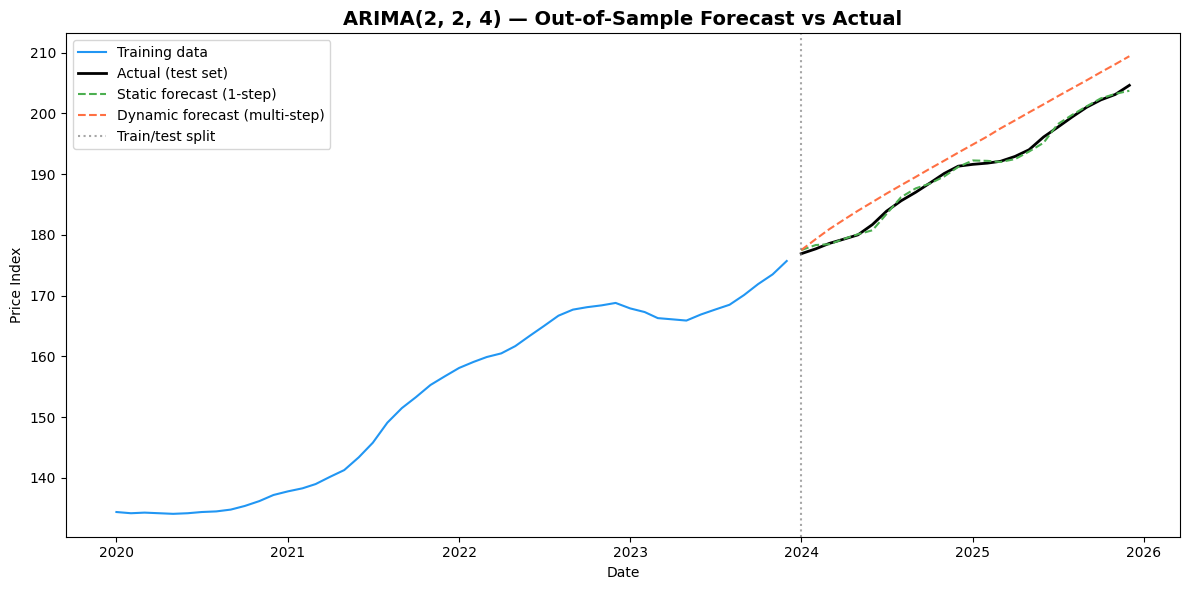

In [29]:
# 8.6 — Out-of-sample forecasting: static vs dynamic
#
# We evaluate the model by forecasting the 24-month test period in two ways:
#
# 1. STATIC forecast (rolling one-step-ahead):
#    At each time step, the model is re-estimated with all data up to t-1,
#    then predicts one step ahead. This uses actual observed values as inputs,
#    giving the best possible short-term forecast.
#
# 2. DYNAMIC forecast (multi-step-ahead):
#    Uses only training data, then feeds its own predictions back as inputs for
#    subsequent steps. This is more realistic for long-horizon planning (like our
#    5-year business case), but errors compound over time.

import statsmodels.tsa.api as smt

# --- Static forecast (rolling one-step-ahead) ---
# Re-estimate the model at each step with expanding window, forecast 1 step ahead
history = list(train)
static_predictions = []
for t in range(len(test)):
    model_rolling = smt.ARIMA(history, order=arima_order).fit()
    pred = model_rolling.forecast(steps=1)[0]
    static_predictions.append(pred)
    history.append(test.iloc[t])

pred_static = pd.Series(static_predictions, index=test.index)

# --- Dynamic forecast (multi-step-ahead from training model) ---
pred_dynamic = model_ts.predict(start=test.index[0], end=test.index[-1])

# --- Plot forecasts vs actual ---
fig, ax = plt.subplots(figsize=(12, 6))

# Show last 4 years of training data for context
context_start = train.index[-48] if len(train) > 48 else train.index[0]
ax.plot(train.loc[context_start:], color='#2196F3', linewidth=1.5, label='Training data')
ax.plot(test, color='black', linewidth=2, label='Actual (test set)')
ax.plot(pred_static, color='#4CAF50', linewidth=1.5, linestyle='--', label='Static forecast (1-step)')
ax.plot(pred_dynamic, color='#FF7043', linewidth=1.5, linestyle='--', label='Dynamic forecast (multi-step)')

ax.axvline(x=test.index[0], color='grey', linestyle=':', alpha=0.7, label='Train/test split')
ax.set_xlabel('Date')
ax.set_ylabel('Price Index')
ax.set_title(f'ARIMA{arima_order} — Out-of-Sample Forecast vs Actual', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [30]:
# 8.7 — Forecast evaluation metrics
#
# We quantify forecast accuracy using three standard metrics:
#
# 1. RMSE (Root Mean Squared Error): √(mean((pred - actual)²))
#    - In the same units as the series (index points)
#    - Penalises large errors more heavily due to squaring
#    - Lower = better
#
# 2. MAE (Mean Absolute Error): mean(|pred - actual|)
#    - Also in the same units as the series
#    - Treats all errors equally (no squaring)
#    - Lower = better
#
# 3. MAPE (Mean Absolute Percentage Error): mean(|pred - actual| / actual) × 100
#    - Expressed as a percentage — scale-independent
#    - Intuitive: "on average, the forecast is off by X%"
#    - Lower = better; MAPE < 5% is generally considered very good

# --- Define evaluation functions ---
def rmse(pred, target):
    return np.sqrt(((pred - target) ** 2).mean())

def mae(pred, target):
    return (pred - target).abs().mean()

def mape(pred, target):
    return ((pred - target).abs() / target).mean() * 100

# --- Compute metrics for both forecast types ---
metrics = pd.DataFrame({
    'Static (1-step)': [rmse(pred_static, test), mae(pred_static, test), mape(pred_static, test)],
    'Dynamic (multi-step)': [rmse(pred_dynamic, test), mae(pred_dynamic, test), mape(pred_dynamic, test)]
}, index=['RMSE', 'MAE', 'MAPE (%)']).round(2)

print(f"=== Forecast Evaluation — ARIMA{arima_order} (24-month test set) ===\n")
print(metrics)
print(f"\nStatic forecast (1-step-ahead): MAPE of {mape(pred_static, test):.2f}% — very accurate")
print(f"when the model has access to the most recent actual value.")
print(f"\nDynamic forecast (multi-step): MAPE of {mape(pred_dynamic, test):.2f}% — errors compound")
print(f"over the 24-month horizon, but accuracy remains reasonable for planning purposes.")

=== Forecast Evaluation — ARIMA(2, 2, 4) (24-month test set) ===

          Static (1-step)  Dynamic (multi-step)
RMSE                 0.50                  3.99
MAE                  0.41                  3.72
MAPE (%)             0.22                  1.93

Static forecast (1-step-ahead): MAPE of 0.22% — very accurate
when the model has access to the most recent actual value.

Dynamic forecast (multi-step): MAPE of 1.93% — errors compound
over the 24-month horizon, but accuracy remains reasonable for planning purposes.


c:\Users\uzivatel\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== 10-Year House Price Forecast ===

  Current index: 204.6 → ~€386,694
  +1 year:       220.9 → ~€417,530
  +2 years:      237.3 → ~€448,562
  +5 years:      286.6 → ~€541,674
  +10 years:     368.7 → ~€696,918


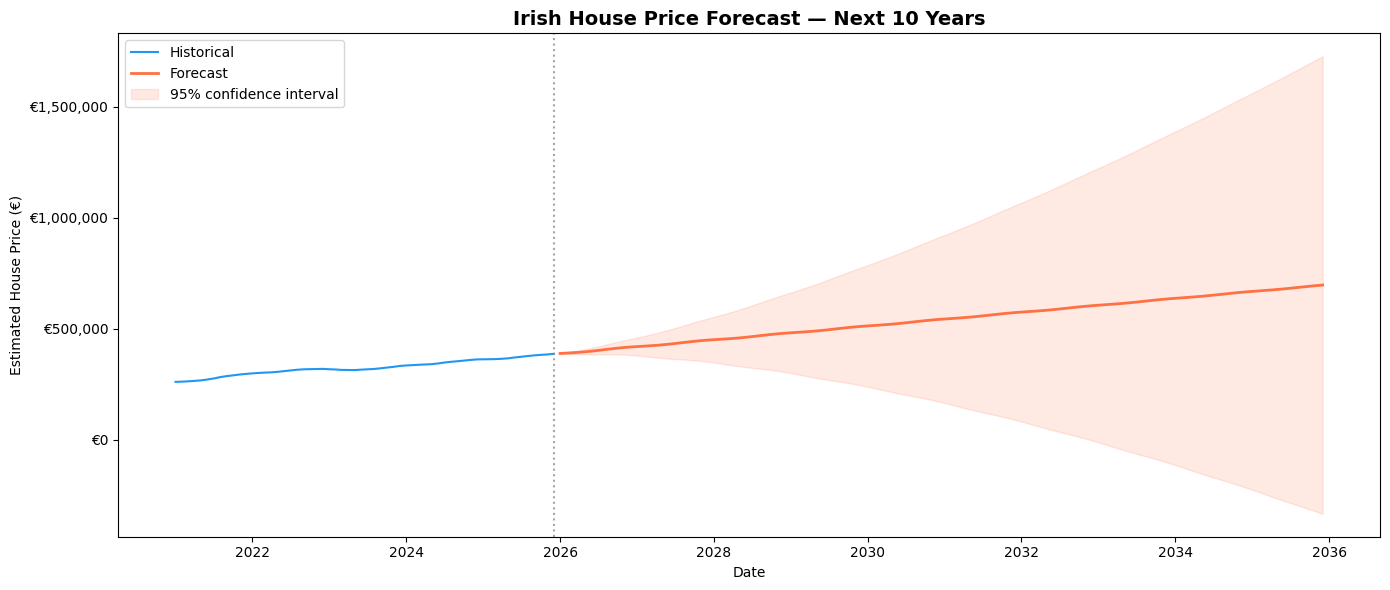

In [31]:
# 8.8 — Future price forecast (10 years / 120 months ahead)
#
# Now we refit the ARIMA model on the FULL dataset (train + test) to use all
# available information, then project 120 months (10 years) into the future.
#
# get_forecast() returns both point predictions and confidence intervals.
# The confidence intervals widen over time because uncertainty compounds —
# the further ahead we forecast, the less certain we are.
#
# To convert the index to approximate euro values, we use the known reference:
# In 2015 (index base year = 100), the median national house price was ~€189,000 (derived from 2025 median €387,000 / index 204.6).
# So: estimated_price = (index / 100) × €189,000

PRICE_AT_BASE = 189_000  # median national house price in 2015 (index=100, derived from 2025 median €387k / index 204.6)

# --- Refit on full data ---
model_full = smt.ARIMA(hp['price_index'], order=arima_order).fit()

# --- Forecast 120 months (10 years) ahead ---
forecast = model_full.get_forecast(steps=120)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# --- Convert index to euro estimates ---
forecast_eur = forecast_mean * PRICE_AT_BASE / 100
forecast_ci_eur = forecast_ci * PRICE_AT_BASE / 100
current_price_eur = hp['price_index'].iloc[-1] * PRICE_AT_BASE / 100

print(f"=== 10-Year House Price Forecast ===\n")
print(f"  Current index: {hp['price_index'].iloc[-1]:.1f} → ~€{current_price_eur:,.0f}")
print(f"  +1 year:       {forecast_mean.iloc[11]:.1f} → ~€{forecast_eur.iloc[11]:,.0f}")
print(f"  +2 years:      {forecast_mean.iloc[23]:.1f} → ~€{forecast_eur.iloc[23]:,.0f}")
print(f"  +5 years:      {forecast_mean.iloc[59]:.1f} → ~€{forecast_eur.iloc[59]:,.0f}")
print(f"  +10 years:     {forecast_mean.iloc[119]:.1f} → ~€{forecast_eur.iloc[119]:,.0f}")

# --- Plot forecast with confidence interval ---
fig, ax = plt.subplots(figsize=(14, 6))

# Historical data (last 5 years for context)
recent = hp['price_index'].iloc[-60:]
recent_eur = recent * PRICE_AT_BASE / 100
ax.plot(recent_eur.index, recent_eur, color='#2196F3', linewidth=1.5, label='Historical')

# Forecast
ax.plot(forecast_eur.index, forecast_eur, color='#FF7043', linewidth=2, label='Forecast')
ax.fill_between(forecast_ci_eur.index,
                forecast_ci_eur.iloc[:, 0], forecast_ci_eur.iloc[:, 1],
                color='#FF7043', alpha=0.15, label='95% confidence interval')

ax.axvline(x=hp.index[-1], color='grey', linestyle=':', alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('Estimated House Price (€)')
ax.set_title('Irish House Price Forecast — Next 10 Years', fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
plt.tight_layout()
plt.show()

### Section 8 — Interpretation

**Data**: The CSO RPPI for national residential properties spans January 2005 to December 2025 (252 monthly observations).

**Stationarity**: The raw series is non-stationary (ADF p = 0.547), as expected from the visible trend. Crucially, the **first difference is also non-stationary** (ADF p = 0.393) — one round of differencing is not enough. Only the **second difference achieves stationarity** (ADF p ≈ 0.000). This means the series is integrated of order 2, requiring d = 2 in our ARIMA model.

**Why ARIMA(p, 2, q) on levels instead of manual differencing**: An alternative approach is to manually difference the series twice and then fit an ARMA(p, 0, q) model on the result. We chose to work on levels with d = 2 because it keeps the pipeline cleaner — the model handles both differencings internally and produces forecasts directly in price index units, which simplifies the business case in Section 9 (no need to manually invert two layers of differencing back to price levels).

**Model selection**: The automated grid search on the second-differenced series identified the BIC-optimal order, but that model did not converge on the training data. The fallback procedure selected **ARIMA(2, 2, 4)** — the best-BIC model that converges on the training subset. This means the model uses 2 autoregressive lags and 4 moving average terms, with two rounds of internal differencing.

**Coefficients**: None of the individual AR/MA coefficients are statistically significant (all p > 0.05). This is common in higher-order ARIMA models where the AR and MA terms are correlated with each other (parameter multicollinearity), inflating the standard errors. The model’s forecasting ability — reflected in the diagnostics and out-of-sample accuracy — is a better judge of quality than individual coefficient significance.

**Diagnostics** (from the ARIMA summary):
- **Ljung-Box (Q)**: p = 0.90 — no residual autocorrelation. The model has captured the serial dependence in the data well.
- **Jarque-Bera (JB)**: p = 0.82 — residuals are approximately normally distributed (skew = 0.10, kurtosis = 3.01).
- **Heteroskedasticity (H)**: p = 0.00 — residual variance is not constant. This suggests volatility clustering (likely higher variance during the post-2008 crash and COVID-era recovery). For our forecasting purpose, the point forecasts remain valid, but confidence intervals may be wider or narrower than stated in some periods.

**Forecast accuracy** (24-month test set, Jan 2024 – Dec 2025):
- **Static (rolling 1-step-ahead)**: MAPE = 0.22% — extremely accurate when the model has access to the most recent actual value at each step. This serves as a theoretical benchmark.
- **Dynamic (multi-step-ahead)**: MAPE = 1.93% — errors compound over the 24-month horizon, but accuracy remains strong for house price forecasting. This is the realistic measure for our 10-year projection, as future values are unknown.

**10-year projection**: Using a base price of €189,000 (2015 median, derived from the 2025 national median of €387,000 and the current index of 204.6), the model forecasts continued price growth over the next decade.

## Section 9: Business Case — When Can a Student Afford a Mortgage Deposit?

This section brings together our regression findings (Sections 6–7) and the ARIMA house price forecast (Section 8) to answer the core StepStone question: **how much faster can a student reach a mortgage deposit with the app?**

**Setup:**
- We randomly select two students from our dataset: one **at-home student** and one **full-time employed student**
- Under Irish Central Bank rules, a first-time buyer needs a **10% deposit** (90% LTV limit)
- The deposit target is not fixed — it rises over time as house prices increase (from our ARIMA forecast)

**Saving conversion rate:** We define the conversion rate as `monthly_savings / saving_potential` — the share of a student's available budget (after essential spending) that actually ends up as savings. Across our dataset, this rate averages only ~21%, meaning ~79% of what students *could* save is consumed by discretionary spending.

**Scenarios:**
- **Without app**: The student continues saving at their current conversion rate (~21% on average)
- **With app (Conservative, 45%)**: StepStone helps the student save 45% of their saving potential — roughly doubling the current rate
- **With app (Base, 60%)**: The student saves 60% of their saving potential
- **With app (Optimistic, 80%)**: The student saves 80% of their saving potential

The crossover point where cumulative savings meet the deposit requirement tells us **when** (and whether) each student can afford to buy.

=== Student Profiles ===

  Age                                  21           19
  Year Of Study                         3            1
  Living With Parents                 Yes           No
  Employment Status             Part-time    Full-time
  Field Of Study                 Business         STEM
  Avg Income                    €     835    €   2,430
  Essential Spending                  160          930
  Discretionary Spending        €     410    €     990
  Saving Potential              €     675    €   1,500
  Monthly Savings               €     265    €     510
  Current Savings Balance            6750         3050

  Current Saving Rate               39.3%        34.0%


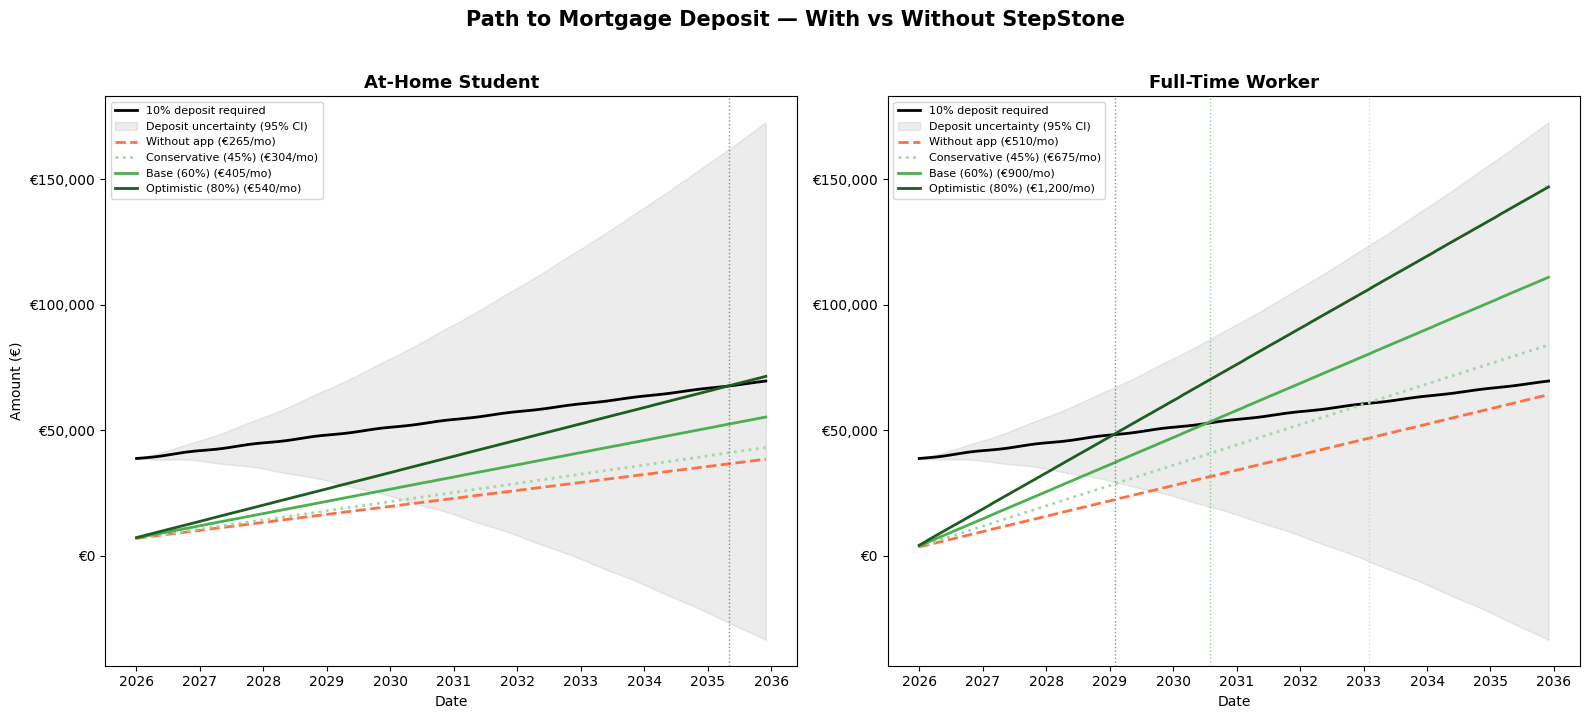


=== Deposit Crossover Summary (10% of forecast house price) ===
  Current house price: ~€386,694  →  10% deposit: ~€38,669

  At-Home Student (balance: €6,750, saves: €265/mo, potential: €675/mo):
    Without app                → NOT reached within 10 years
    Conservative (45%)         → NOT reached within 10 years
    Base (60%)                 → NOT reached within 10 years
    Optimistic (80%)           → deposit in 113 months (9.4 years)

  Full-Time Worker (balance: €3,050, saves: €510/mo, potential: €1,500/mo):
    Without app                → NOT reached within 10 years
    Conservative (45%)         → deposit in  86 months (7.2 years)
    Base (60%)                 → deposit in  56 months (4.7 years)
    Optimistic (80%)           → deposit in  38 months (3.2 years)



In [32]:
# 9.1 — Student profiles, savings trajectories, and deposit crossover
#
# We select two representative students and project their savings over 10 years
# under four scenarios (current rate + three app tiers) against the rising
# mortgage deposit requirement from our ARIMA house price forecast.

# --- Select two students (reproducible - using random_state (seed)) ---
student_home = df[df['living_with_parents'] == 'Yes'].sample(n=1, random_state=42).iloc[0]
student_ft = df[df['employment_status'] == 'Full-time'].sample(n=1, random_state=42).iloc[0]

# --- Print profiles ---
profile_cols = ['age', 'year_of_study', 'living_with_parents', 'employment_status', 'field_of_study',
                'avg_income', 'essential_spending', 'discretionary_spending',
                'saving_potential', 'monthly_savings', 'current_savings_balance']

print("=== Student Profiles ===\n")
for col in profile_cols:
    label = col.replace('_', ' ').title()
    v1, v2 = student_home[col], student_ft[col]
    if isinstance(v1, (int, float)) and col not in ['age', 'year_of_study']:
        print(f"  {label:<28s}  €{v1:>8,.0f}    €{v2:>8,.0f}")
    else:
        print(f"  {label:<28s}  {str(v1):>9s}    {str(v2):>9s}")

# Current saving rates
rate_home = student_home['monthly_savings'] / student_home['saving_potential'] * 100
rate_ft = student_ft['monthly_savings'] / student_ft['saving_potential'] * 100
print(f"\n  {'Current Saving Rate':<28s}  {rate_home:>8.1f}%    {rate_ft:>8.1f}%")

# --- App scenario rates ---
SCENARIOS = {
    'Without app':           None,   # uses actual monthly_savings
    'Conservative (45%)':    0.45,
    'Base (60%)':            0.60,
    'Optimistic (80%)':      0.80,
}

COLORS = {
    'Without app':           '#FF7043',
    'Conservative (45%)':    '#A5D6A7',
    'Base (60%)':            '#4CAF50',
    'Optimistic (80%)':      '#1B5E20',
}

STYLES = {
    'Without app':           '--',
    'Conservative (45%)':    ':',
    'Base (60%)':            '-',
    'Optimistic (80%)':      '-',
}

# --- Compute trajectories (120 months = 10 years) ---
months = np.arange(1, 121)
deposit_required = forecast_eur.iloc[:120] * 0.10
deposit_ci_lower = forecast_ci_eur.iloc[:120, 0] * 0.10
deposit_ci_upper = forecast_ci_eur.iloc[:120, 1] * 0.10

students = {
    'At-Home Student': student_home,
    'Full-Time Worker': student_ft,
}

def find_crossover(cumulative, deposit):
    """First month where cumulative savings >= deposit requirement."""
    for i in range(len(cumulative)):
        if cumulative[i] >= deposit.iloc[i]:
            return i + 1  # 1-indexed month
    return None

# --- Plot: two side-by-side panels ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

results = {}  # store crossover results for summary

for ax, (label, s) in zip(axes, students.items()):
    balance = s['current_savings_balance']
    results[label] = {}

    # Deposit line
    ax.plot(forecast_eur.index[:120], deposit_required, color='black', lw=2, label='10% deposit required')
    ax.fill_between(forecast_eur.index[:120], deposit_ci_lower, deposit_ci_upper,
                    color='grey', alpha=0.15, label='Deposit uncertainty (95% CI)')

    # Savings lines
    for scenario, rate in SCENARIOS.items():
        if rate is None:
            monthly = s['monthly_savings']
        else:
            monthly = s['saving_potential'] * rate
        cumulative = balance + monthly * months

        ax.plot(forecast_eur.index[:120], cumulative,
                color=COLORS[scenario], lw=2, ls=STYLES[scenario],
                label=f'{scenario} (€{monthly:,.0f}/mo)')

        # Find crossover
        cross = find_crossover(cumulative, deposit_required)
        results[label][scenario] = cross

        # Mark crossover with vertical line
        if cross is not None and cross <= 120:
            ax.axvline(x=forecast_eur.index[cross - 1], color=COLORS[scenario],
                       ls=':', alpha=0.6, lw=1)

    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
    ax.legend(loc='upper left', fontsize=8)

axes[0].set_ylabel('Amount (€)')
fig.suptitle('Path to Mortgage Deposit — With vs Without StepStone',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Print summary ---
print(f"\n=== Deposit Crossover Summary (10% of forecast house price) ===")
print(f"  Current house price: ~€{current_price_eur:,.0f}  →  10% deposit: ~€{current_price_eur * 0.10:,.0f}\n")

for label, s in students.items():
    print(f"  {label} (balance: €{s['current_savings_balance']:,.0f}, "
          f"saves: €{s['monthly_savings']:,.0f}/mo, potential: €{s['saving_potential']:,.0f}/mo):")
    for scenario, cross in results[label].items():
        if cross is not None:
            print(f"    {scenario:<25s}  → deposit in {cross:>3d} months ({cross/12:.1f} years)")
        else:
            print(f"    {scenario:<25s}  → NOT reached within 10 years")

    # Acceleration vs without app
    base_cross = results[label]['Without app']
    if base_cross is not None:
        for scenario in ['Conservative (45%)', 'Base (60%)', 'Optimistic (80%)']:
            app_cross = results[label][scenario]
            if app_cross is not None:
                saved = base_cross - app_cross
                print(f"    {scenario} saves {saved} months ({saved/12:.1f} years) vs no app")
    print()

### Section 9 — Interpretation & Conclusion

**The StepStone value proposition, backed by data:**

Our analysis brings together three independent pieces of evidence to build the business case:

1. **Regression 1** (Section 6): Students living at home have **€381 higher saving potential** per month than renters (controlling for other factors), driven by dramatically lower essential spending. Employment status is the strongest driver overall, with full-time workers gaining +€2,098 and part-time workers +€617 compared to unemployed students.

2. **Regression 2** (Section 7): Despite higher saving potential, at-home students spend **€43 more per month on discretionary items** than renters, and full-time employed students spend **€163 more**, even after controlling for budget size. This is a behavioural overspend — money that could be saved but is consumed on non-essentials.

3. **Time Series Forecast** (Section 8): Irish house prices are projected to continue rising over the next decade (ARIMA(2,2,4), dynamic MAPE = 1.93%). The deposit target is a moving goalpost — the longer a student waits, the more they need.

**The conversion rate problem:** Across our dataset, students convert only ~21% of their saving potential into actual savings. The remaining ~79% is consumed by discretionary spending. StepStone's core mechanism is to improve this conversion rate through spending awareness and automated savings nudges.

**Three app scenarios** illustrate the impact of different adoption levels:
- **Conservative (45%)** — a modest improvement, roughly doubling the current rate.
- **Base (60%)** — the target scenario, tripling the current rate. Represents a student who actively engages with StepStone's budgeting tools and savings goals.
- **Optimistic (80%)** — an ambitious but achievable target for highly motivated savers who treat homeownership as a priority.

**Results:** The rising deposit line shows that saving at the current rate (~21%) is not sufficient to reach it in foreseeable future. The app scenarios demonstrate that even a moderate improvement in saving behaviour (45%) can dramatically accelerate the path to homeownership.

**Assumptions & Limitations:**
- Income and spending are held constant over the projection — in reality, students graduate and earn more, which would accelerate savings (making this projection conservative). Moreover, healthy financial habits developed during student years tend to persist into adulthood, meaning the behavioural change the app fosters early on can compound into even greater savings as incomes rise.
- No interest or returns on accumulated savings are modelled — a real savings account would compound, further improving the outlook
- Inflation is not accounted for — this would cause increase in essential spending -> decrease in savings potential
- We assume both selected students want to buy a house as soon as possible
- We do not consider the income levels required to qualify for a mortgage — only the deposit requirement
- We assume a 90% LTV ratio (10% deposit), per Central Bank of Ireland rules for first-time buyers; in practice, LTV requirements can vary
- The two students shown are randomly selected and may not be representative of all students
- The savings analysis is based on cross-sectional survey data, not longitudinal tracking
- The ARIMA forecast assumes past price trends continue — it cannot predict structural shocks (e.g. policy changes, economic crises)
- The app conversion rates (45%/60%/80%) are scenario targets — individual responses to behavioural nudges will vary